# BÀI TỔNG HỢP 07 LAB – PHÂN TÍCH DỮ LIỆU VÀ HỌC SÂU

**Họ và tên:** Ngô Anh Tuấn  
**MSSV:** 2174802010464  

In [1]:
# Thiết lập chung cho toàn bộ notebook
import os
import io
import re
import gzip
import base64
import random
import string
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

sns.set_theme(style='whitegrid', palette='deep')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Giảm số luồng để các phần PyTorch chạy ổn định trên CPU.
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['MKL_NUM_THREADS'] = '1'

print('Thiết lập môi trường thành công.')

Thiết lập môi trường thành công.


# LAB 01: BÀI THỰC HÀNH THAO TÁC DỮ LIỆU

## Phần 01: Chuẩn bị dữ liệu

### 01. Nạp dữ liệu tuyển sinh

Nếu file `dulieuxettuyendaihoc.csv` có trong thư mục làm việc, notebook sẽ dùng file đó. Nếu không, notebook tạo bộ dữ liệu thực hành có cùng cấu trúc để bảo đảm các bước xử lý vẫn chạy đầy đủ.

In [2]:
def create_admission_dataset(n=100, seed=42):
    rng = np.random.default_rng(seed)
    data = {'STT': np.arange(1, n + 1)}
    subjects = ['T', 'L', 'H', 'S', 'V', 'X', 'D', 'N']

    for grade in range(1, 7):
        for subject in subjects:
            values = np.clip(rng.normal(6.4, 1.45, n), 1.0, 10.0)
            data[f'{subject}{grade}'] = np.round(values, 1)

    data['GT'] = rng.choice(['M', 'F'], size=n, p=[0.52, 0.48])
    data['DT'] = rng.choice([0.0, 1.0, 2.0, 6.0, np.nan], size=n,
                            p=[0.87, 0.04, 0.025, 0.015, 0.05])
    data['KV'] = rng.choice(['1', '2', '2NT'], size=n, p=[0.42, 0.34, 0.24])
    data['KT'] = rng.choice(['A', 'A1', 'B', 'C', 'D1'], size=n,
                            p=[0.42, 0.12, 0.12, 0.16, 0.18])

    for col in ['DH1', 'DH2', 'DH3']:
        values = np.clip(np.round(rng.normal(5.2, 1.5, n) * 4) / 4, 1.0, 10.0)
        data[col] = values

    df_generated = pd.DataFrame(data)
    # Chủ động tạo một số giá trị thiếu để thực hành làm sạch.
    df_generated.loc[[5, 25, 74], 'T1'] = np.nan
    df_generated.loc[[9, 39], 'L2'] = np.nan
    # Bảo đảm các tập lọc trong Lab 02 không rỗng.
    df_generated.loc[0, ['GT', 'DT', 'KV', 'KT', 'DH1', 'DH2', 'DH3']] = ['M', 0.0, '2NT', 'A', 6.0, 6.0, 6.0]
    df_generated.loc[1, ['GT', 'DT', 'KV', 'KT', 'DH1', 'DH2', 'DH3']] = ['M', 0.0, '1', 'A1', 5.5, 5.0, 5.0]
    df_generated.loc[2, ['GT', 'DT', 'KV', 'KT', 'DH1', 'DH2', 'DH3']] = ['F', 0.0, '2', 'B', 6.0, 6.5, 5.5]
    return df_generated

source_path = Path('dulieuxettuyendaihoc.csv')
if source_path.exists():
    df = pd.read_csv(source_path)
    data_source_lab1 = 'file dulieuxettuyendaihoc.csv'
else:
    df = create_admission_dataset()
    data_source_lab1 = 'bộ dữ liệu dự phòng tích hợp'

print(f'Nguồn dữ liệu: {data_source_lab1}')
print(f'Kích thước dữ liệu: {df.shape}')
display(df.head(10))

Nguồn dữ liệu: bộ dữ liệu dự phòng tích hợp
Kích thước dữ liệu: (100, 56)


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3
0,1,6.8,5.9,6.9,8.9,6.1,8.4,7.1,8.0,5.2,7.0,6.3,8.0,4.5,6.5,8.1,5.6,6.3,4.8,6.3,5.6,5.7,6.8,5.6,5.7,5.8,7.2,5.6,7.6,6.0,5.6,8.2,4.9,5.6,7.2,7.0,6.0,7.8,6.3,5.9,7.3,6.8,7.2,5.2,5.8,6.3,4.2,7.5,7.5,M,0.0,2NT,A,6.00,6.00,6.00
1,2,4.9,8.3,8.4,4.2,6.7,7.7,5.6,6.0,4.8,6.5,5.3,7.3,5.7,3.4,5.9,5.5,8.0,5.7,7.0,8.0,5.4,3.9,6.1,5.1,7.8,6.8,8.4,4.8,7.8,4.4,7.4,5.6,8.1,9.4,7.6,8.3,9.9,5.1,5.3,7.4,7.7,6.6,3.5,8.0,5.7,8.0,6.5,5.7,M,0.0,1,A1,5.50,5.00,5.00
2,3,7.5,5.9,6.5,7.7,7.6,5.4,8.2,4.9,6.9,6.2,5.8,7.3,7.0,7.3,6.1,8.3,8.2,6.6,6.0,7.3,7.0,5.4,6.5,2.4,6.8,7.9,6.3,7.6,7.7,7.9,9.3,7.5,6.0,7.8,5.4,7.3,4.4,5.3,6.1,4.2,6.8,5.3,7.2,5.4,5.4,4.5,6.3,3.8,F,0.0,2,B,6.00,6.50,5.50
3,4,7.8,7.5,7.3,5.9,5.8,4.2,5.5,6.3,6.9,8.7,7.3,7.2,6.3,7.5,5.7,6.9,4.3,3.0,5.8,6.2,6.8,7.5,7.3,5.8,5.4,7.1,6.7,8.1,5.0,5.6,4.2,7.9,8.0,7.8,7.9,4.7,8.5,5.3,6.8,6.1,9.6,9.1,9.5,5.5,8.6,7.6,7.2,6.8,F,0.0,2,A,4.25,6.25,2.50
4,5,3.6,5.0,3.4,6.3,7.2,2.1,5.5,7.9,8.3,5.5,6.4,4.8,5.5,6.0,5.6,6.1,5.9,6.7,6.5,7.3,4.4,6.0,8.0,6.9,5.1,8.2,8.1,6.7,5.2,5.8,6.0,6.3,7.0,10.0,4.2,6.6,6.5,7.2,7.8,4.1,8.5,5.9,8.4,6.4,6.3,5.4,6.2,7.5,M,0.0,2,A1,4.75,5.75,7.00
5,6,NaN,6.1,6.3,4.9,6.0,5.6,7.2,5.0,8.0,9.4,6.9,7.4,5.4,2.8,7.4,7.1,8.4,9.2,3.6,4.7,8.0,5.7,6.0,5.7,4.0,7.7,5.1,6.1,6.6,6.5,5.7,6.5,5.9,7.1,4.6,8.8,7.6,6.1,2.6,9.9,6.0,7.5,6.0,6.4,8.2,8.7,6.7,7.2,M,0.0,1,A1,5.50,4.00,4.75
6,7,6.6,5.0,5.2,5.9,6.2,9.9,7.5,5.1,6.2,6.1,7.4,4.4,5.4,5.0,6.8,3.3,7.1,5.7,7.1,6.4,6.3,8.4,5.7,9.2,6.8,8.6,5.0,7.0,8.9,8.1,3.5,7.5,7.1,7.1,7.4,6.1,4.0,6.1,5.2,4.1,5.9,2.9,6.4,6.8,5.6,7.5,4.9,7.0,M,0.0,2,A,4.50,4.00,6.25
7,8,5.9,5.9,4.6,8.3,7.6,7.0,7.0,7.2,4.6,4.5,5.9,5.2,5.1,8.2,7.3,6.3,6.7,6.8,6.4,6.6,4.8,4.9,7.0,6.4,5.9,6.9,6.1,2.3,3.6,6.4,7.9,6.6,6.9,7.4,8.8,7.0,8.5,7.3,6.6,4.9,7.1,8.3,7.7,9.4,6.8,4.9,8.3,5.9,M,0.0,1,A,3.75,6.75,3.25
8,9,6.4,7.6,5.1,7.2,3.5,5.6,4.0,6.1,5.9,6.5,7.5,8.3,9.7,2.4,6.4,9.3,6.1,7.9,6.5,5.7,8.1,5.2,7.3,8.3,3.0,7.7,7.6,6.8,6.8,4.7,6.0,4.5,7.9,4.9,7.1,7.2,7.5,6.2,6.3,4.9,5.2,8.5,8.0,6.9,6.3,5.1,4.7,5.2,F,0.0,2NT,A,3.50,7.00,5.25
9,10,5.2,3.9,5.9,8.9,4.5,7.1,7.2,7.3,6.7,NaN,6.9,7.6,6.8,5.9,7.1,6.6,5.8,6.2,7.8,7.0,7.3,6.7,5.8,6.8,5.6,6.0,4.5,6.2,4.4,7.2,7.5,5.2,5.6,5.8,6.3,4.9,6.3,6.0,7.0,4.2,8.1,6.4,5.9,3.0,3.9,7.3,5.8,7.2,M,0.0,2NT,A,2.75,7.50,5.50


## Phần 02: Khảo sát và phân loại dữ liệu

### 01. Hiển thị dữ liệu cuối bảng và thông tin DataFrame

In [3]:
print('10 dòng cuối:')
display(df.tail(10))
print('\nThông tin DataFrame:')
df.info()

10 dòng cuối:


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3
90,91,7.4,8.9,6.0,3.1,8.0,4.6,6.9,5.3,5.2,7.7,5.5,8.6,6.6,5.4,5.5,4.4,5.6,4.0,7.9,7.0,6.7,7.5,7.0,3.6,7.6,5.2,4.5,8.5,5.2,7.3,8.2,4.3,6.1,4.8,4.6,6.3,7.4,5.7,4.6,6.8,9.7,7.9,5.8,6.7,9.0,7.6,8.0,3.9,M,0.0,2,A1,5.75,7.00,6.50
91,92,6.3,6.1,6.6,6.5,6.9,6.8,6.0,4.6,5.6,8.5,6.4,7.9,5.8,8.5,6.4,4.4,4.1,6.4,5.3,7.2,7.3,5.0,8.1,7.4,5.4,9.5,4.9,6.2,7.0,8.8,5.4,5.2,6.8,3.9,5.0,8.4,6.3,8.6,4.4,4.9,6.5,7.6,4.1,8.3,5.1,8.6,6.8,1.9,F,0.0,1,A,3.75,3.25,8.00
92,93,5.8,5.8,8.5,5.7,6.0,9.0,7.8,7.1,5.8,9.0,7.6,6.0,5.8,5.6,5.5,6.1,4.4,6.8,4.8,6.7,6.6,5.0,8.1,4.0,7.5,7.1,6.3,5.3,6.3,6.3,7.8,6.5,5.7,5.2,6.0,9.0,3.6,5.9,3.0,6.0,5.3,7.2,5.1,4.8,5.3,6.7,6.8,7.5,M,0.0,2NT,A,4.00,4.75,4.25
93,94,6.3,8.5,2.7,7.1,7.1,4.0,3.1,7.0,6.5,8.3,6.7,7.5,3.3,7.1,4.8,5.3,5.6,6.0,3.3,7.8,7.6,6.5,5.8,6.8,5.3,7.4,5.9,5.7,5.4,9.9,5.3,4.7,7.2,4.9,6.8,7.0,4.5,7.4,4.9,5.4,4.7,4.9,8.3,5.1,5.0,6.0,5.3,6.3,F,6.0,2NT,B,6.50,3.75,3.75
94,95,4.0,4.8,6.1,7.4,6.0,4.5,5.2,3.8,5.9,6.2,5.4,9.2,6.8,3.7,5.9,6.9,4.6,3.7,6.0,6.5,6.5,6.7,8.1,5.1,8.0,4.1,8.4,8.0,5.4,5.7,9.0,6.2,5.6,7.2,8.5,5.9,8.3,4.3,7.3,7.3,7.2,8.3,6.5,4.7,6.9,7.5,6.2,8.1,M,0.0,1,A,7.75,4.75,4.00
95,96,4.3,5.1,6.7,6.6,7.8,5.8,5.3,6.2,7.9,6.9,8.2,9.2,7.6,9.1,4.8,7.1,7.0,5.9,5.6,7.0,7.5,3.7,7.7,4.7,9.6,5.2,7.8,7.4,4.6,5.3,4.8,7.9,7.3,7.3,6.3,10.0,5.3,6.2,4.1,5.4,3.8,5.2,7.1,6.8,4.4,7.7,6.9,5.1,M,2.0,2,A,6.00,7.50,4.75
96,97,4.5,7.3,6.8,7.5,3.7,5.6,3.0,7.8,5.4,7.5,8.7,4.6,4.1,7.3,6.9,6.9,5.7,5.9,4.2,6.8,7.7,6.1,10.0,5.8,6.2,8.2,7.1,7.2,7.8,4.6,8.3,4.5,7.0,5.1,7.9,5.8,5.4,4.0,4.4,7.9,7.2,6.8,6.0,6.5,5.7,5.9,7.4,6.9,M,0.0,1,A,3.75,3.00,1.75
97,98,5.0,5.8,5.9,6.7,5.9,7.6,5.0,7.9,5.1,6.6,7.1,5.1,5.4,6.1,4.7,6.7,9.8,6.2,7.1,6.3,5.2,6.4,5.3,6.1,3.2,6.8,6.6,6.0,6.5,9.8,5.4,6.1,6.3,6.0,8.0,5.6,6.2,4.9,9.0,6.0,7.6,4.0,5.4,5.7,3.3,6.9,6.3,7.6,M,0.0,1,D1,5.75,2.75,5.00
98,99,7.0,6.4,3.9,7.2,3.5,6.8,5.1,7.9,7.1,6.6,7.8,8.6,4.7,7.2,7.4,8.7,3.9,5.6,5.7,5.6,3.8,6.1,5.7,5.5,5.6,3.6,7.0,7.2,5.1,7.6,9.3,7.9,5.8,3.7,6.1,3.8,4.9,7.6,5.5,5.5,7.0,3.4,8.8,4.9,6.7,8.1,8.0,5.8,F,0.0,1,A,8.75,4.00,4.50
99,100,5.1,6.2,6.9,5.4,4.2,3.8,6.1,6.5,4.2,7.6,8.2,4.9,5.0,4.4,4.7,4.9,6.7,5.8,4.8,9.6,8.6,5.2,6.0,7.3,8.2,7.9,5.2,5.5,7.6,5.9,7.3,5.8,6.6,5.7,7.3,8.4,4.6,6.3,6.9,4.6,6.1,6.9,6.1,4.6,5.7,9.1,6.4,5.8,M,0.0,1,A,5.25,5.75,6.50



Thông tin DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 56 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   STT     100 non-null    int64  
 1   T1      97 non-null     float64
 2   L1      100 non-null    float64
 3   H1      100 non-null    float64
 4   S1      100 non-null    float64
 5   V1      100 non-null    float64
 6   X1      100 non-null    float64
 7   D1      100 non-null    float64
 8   N1      100 non-null    float64
 9   T2      100 non-null    float64
 10  L2      98 non-null     float64
 11  H2      100 non-null    float64
 12  S2      100 non-null    float64
 13  V2      100 non-null    float64
 14  X2      100 non-null    float64
 15  D2      100 non-null    float64
 16  N2      100 non-null    float64
 17  T3      100 non-null    float64
 18  L3      100 non-null    float64
 19  H3      100 non-null    float64
 20  S3      100 non-null    float64
 21  V3      100 non-nu

### 02. Xác định dữ liệu định tính, định lượng và thang đo

- **Định lượng:** các biến điểm `T1...N6`, `DH1`, `DH2`, `DH3` và các biến điểm trung bình được tạo sau đó.
- **Định tính:** `GT`, `DT`, `KV`, `KT`; `STT` là mã định danh.
- **Định danh:** `STT`, `GT`, `DT`, `KV`, `KT`.
- **Thứ bậc:** các biến xếp loại `XL1`, `XL2`, `XL3`.
- **Tỉ lệ:** các biến điểm số.

## Phần 03: Xử lý dữ liệu thiếu

### 01. Xử lý dữ liệu thiếu của cột DT

In [4]:
print("Số giá trị thiếu trong DT trước xử lý:", df['DT'].isna().sum())
df['DT'] = df['DT'].fillna(0)
print("Số giá trị thiếu trong DT sau xử lý:", df['DT'].isna().sum())
display(df[df['DT'] == 0].head())

Số giá trị thiếu trong DT trước xử lý: 4
Số giá trị thiếu trong DT sau xử lý: 0


,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3
0,1,6.8,5.9,6.9,8.9,6.1,8.4,7.1,8.0,5.2,7.0,6.3,8.0,4.5,6.5,8.1,5.6,6.3,4.8,6.3,5.6,5.7,6.8,5.6,5.7,5.8,7.2,5.6,7.6,6.0,5.6,8.2,4.9,5.6,7.2,7.0,6.0,7.8,6.3,5.9,7.3,6.8,7.2,5.2,5.8,6.3,4.2,7.5,7.5,M,0.0,2NT,A,6.00,6.00,6.0
1,2,4.9,8.3,8.4,4.2,6.7,7.7,5.6,6.0,4.8,6.5,5.3,7.3,5.7,3.4,5.9,5.5,8.0,5.7,7.0,8.0,5.4,3.9,6.1,5.1,7.8,6.8,8.4,4.8,7.8,4.4,7.4,5.6,8.1,9.4,7.6,8.3,9.9,5.1,5.3,7.4,7.7,6.6,3.5,8.0,5.7,8.0,6.5,5.7,M,0.0,1,A1,5.50,5.00,5.0
2,3,7.5,5.9,6.5,7.7,7.6,5.4,8.2,4.9,6.9,6.2,5.8,7.3,7.0,7.3,6.1,8.3,8.2,6.6,6.0,7.3,7.0,5.4,6.5,2.4,6.8,7.9,6.3,7.6,7.7,7.9,9.3,7.5,6.0,7.8,5.4,7.3,4.4,5.3,6.1,4.2,6.8,5.3,7.2,5.4,5.4,4.5,6.3,3.8,F,0.0,2,B,6.00,6.50,5.5
3,4,7.8,7.5,7.3,5.9,5.8,4.2,5.5,6.3,6.9,8.7,7.3,7.2,6.3,7.5,5.7,6.9,4.3,3.0,5.8,6.2,6.8,7.5,7.3,5.8,5.4,7.1,6.7,8.1,5.0,5.6,4.2,7.9,8.0,7.8,7.9,4.7,8.5,5.3,6.8,6.1,9.6,9.1,9.5,5.5,8.6,7.6,7.2,6.8,F,0.0,2,A,4.25,6.25,2.5
4,5,3.6,5.0,3.4,6.3,7.2,2.1,5.5,7.9,8.3,5.5,6.4,4.8,5.5,6.0,5.6,6.1,5.9,6.7,6.5,7.3,4.4,6.0,8.0,6.9,5.1,8.2,8.1,6.7,5.2,5.8,6.0,6.3,7.0,10.0,4.2,6.6,6.5,7.2,7.8,4.1,8.5,5.9,8.4,6.4,6.3,5.4,6.2,7.5,M,0.0,2,A1,4.75,5.75,7.0


### 02. Điền giá trị thiếu cho các cột điểm bằng trung bình

In [5]:
score_columns = [c for c in df.columns if len(c) >= 2 and c[0] in list('TLHSVXDN') and c[1:].isdigit()]
score_columns += ['DH1', 'DH2', 'DH3']

imputation_log = []
for col in score_columns:
    missing = int(df[col].isna().sum())
    if missing:
        mean_value = float(df[col].mean())
        df[col] = df[col].fillna(mean_value)
        imputation_log.append([col, missing, round(mean_value, 3)])

display(pd.DataFrame(imputation_log, columns=['Cột', 'Số ô đã điền', 'Giá trị trung bình']))
print('Tổng số giá trị thiếu còn lại trong nhóm cột điểm:', int(df[score_columns].isna().sum().sum()))

,Cột,Số ô đã điền,Giá trị trung bình
0,T1,3,6.349
1,L2,2,6.561


Tổng số giá trị thiếu còn lại trong nhóm cột điểm: 0


## Phần 04: Tạo biến mới

### 01. Tạo TBM1, TBM2 và TBM3

In [6]:
for grade in [1, 2, 3]:
    df[f'TBM{grade}'] = (
        df[f'T{grade}'] * 2 + df[f'L{grade}'] + df[f'H{grade}'] +
        df[f'S{grade}'] + df[f'V{grade}'] * 2 + df[f'X{grade}'] +
        df[f'D{grade}'] + df[f'N{grade}']
    ) / 10
    df[f'TBM{grade}'] = df[f'TBM{grade}'].round(2)

display(df[['TBM1', 'TBM2', 'TBM3']].head())

,TBM1,TBM2,TBM3
0,7.10,6.09,5.88
1,6.34,5.49,6.26
2,6.88,6.88,6.46
3,6.39,6.97,5.78
4,5.18,6.20,6.20


### 02. Tạo XL1, XL2 và XL3

In [7]:
def categorize_performance(score):
    if score < 5.0:
        return 'Y'
    if score < 6.5:
        return 'TB'
    if score < 8.0:
        return 'K'
    if score < 9.0:
        return 'G'
    return 'XS'

for grade in [1, 2, 3]:
    df[f'XL{grade}'] = df[f'TBM{grade}'].apply(categorize_performance)

display(df[['TBM1', 'XL1', 'TBM2', 'XL2', 'TBM3', 'XL3']].head())

,TBM1,XL1,TBM2,XL2,TBM3,XL3
0,7.10,K,6.09,TB,5.88,TB
1,6.34,TB,5.49,TB,6.26,TB
2,6.88,K,6.88,K,6.46,TB
3,6.39,TB,6.97,K,5.78,TB
4,5.18,TB,6.20,TB,6.20,TB


### 03. Chuyển TBM sang thang điểm 4 của Mỹ

In [8]:
for grade in [1, 2, 3]:
    df[f'US_TBM{grade}'] = (df[f'TBM{grade}'] * 0.4).round(3)

display(df[['TBM1', 'US_TBM1', 'TBM2', 'US_TBM2', 'TBM3', 'US_TBM3']].head())

,TBM1,US_TBM1,TBM2,US_TBM2,TBM3,US_TBM3
0,7.10,2.840,6.09,2.436,5.88,2.352
1,6.34,2.536,5.49,2.196,6.26,2.504
2,6.88,2.752,6.88,2.752,6.46,2.584
3,6.39,2.556,6.97,2.788,5.78,2.312
4,5.18,2.072,6.20,2.480,6.20,2.480


### 04. Tạo biến kết quả xét tuyển KQXT

In [9]:
def calculate_kqxt(row):
    if row['KT'] in ['A', 'A1']:
        score = (row['DH1'] * 2 + row['DH2'] + row['DH3']) / 4
    elif row['KT'] == 'B':
        score = (row['DH1'] + row['DH2'] * 2 + row['DH3']) / 4
    else:
        score = (row['DH1'] + row['DH2'] + row['DH3']) / 3
    return int(score >= 5.0)

df['KQXT'] = df.apply(calculate_kqxt, axis=1)
display(df[['KT', 'DH1', 'DH2', 'DH3', 'KQXT']].head(10))

,KT,DH1,DH2,DH3,KQXT
0,A,6.00,6.00,6.00,1
1,A1,5.50,5.00,5.00,1
2,B,6.00,6.50,5.50,1
3,A,4.25,6.25,2.50,0
4,A1,4.75,5.75,7.00,1
5,A1,5.50,4.00,4.75,0
6,A,4.50,4.00,6.25,0
7,A,3.75,6.75,3.25,0
8,A,3.50,7.00,5.25,0
9,A,2.75,7.50,5.50,0


## Phần 05: Lưu dữ liệu

### 01. Xuất file processed_dulieuxettuyendaihoc.csv

In [10]:
processed_path = Path('processed_dulieuxettuyendaihoc.csv')
df.to_csv(processed_path, index=False)
print(f'Đã lưu: {processed_path.resolve()} – {processed_path.stat().st_size:,} bytes')

Đã lưu: /mnt/data/processed_dulieuxettuyendaihoc.csv – 26,426 bytes


# LAB 02: BÀI THỰC HÀNH TRÌNH BÀY DỮ LIỆU

## Phần 01: Thống kê dữ liệu

### 01. Nạp dữ liệu đã xử lý và sắp xếp điểm DH1

In [11]:
df2 = pd.read_csv('processed_dulieuxettuyendaihoc.csv')
df_sorted_DH1 = df2.sort_values('DH1', ascending=True)
display(df_sorted_DH1.head())

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
26,27,7.2,8.5,10.0,4.1,7.6,8.5,5.8,6.8,6.4,6.200000,3.2,9.0,7.5,6.8,7.6,8.1,3.0,5.0,7.6,5.6,7.2,9.6,6.6,3.2,9.5,6.3,8.4,5.1,9.1,7.6,7.5,6.3,5.1,7.2,7.0,7.0,6.5,6.7,7.6,7.5,5.5,7.9,7.0,7.9,6.6,6.1,5.6,5.9,F,0.0,2NT,A1,2.25,3.00,3.50,7.33,6.87,5.80,K,K,TB,2.932,2.748,2.320,0
72,73,5.1,5.7,6.3,7.6,6.0,6.8,5.4,6.8,7.5,6.700000,6.1,6.2,5.9,7.0,6.4,6.9,6.6,4.5,5.5,6.6,3.5,6.0,7.3,6.2,6.9,8.5,5.7,6.0,4.8,6.4,4.1,7.8,6.1,4.3,8.0,6.9,7.2,7.0,5.7,6.7,6.2,6.5,7.0,4.8,9.0,6.9,7.2,5.9,F,0.0,1,D1,2.25,8.00,7.50,6.08,6.61,5.63,TB,K,TB,2.432,2.644,2.252,1
80,81,7.1,8.3,7.1,6.6,6.7,2.9,7.6,6.3,6.7,7.100000,6.8,4.5,8.1,8.2,7.1,8.1,4.2,7.6,7.5,6.6,7.0,9.5,8.2,6.0,9.0,5.0,8.2,8.6,6.8,6.3,5.7,5.0,8.9,6.7,5.7,7.3,5.5,6.9,5.7,6.9,8.0,8.1,8.4,9.2,6.7,5.9,8.7,5.9,M,0.0,1,B,2.50,6.50,3.50,6.64,7.14,6.78,K,K,K,2.656,2.856,2.712,0
9,10,5.2,3.9,5.9,8.9,4.5,7.1,7.2,7.3,6.7,6.561224,6.9,7.6,6.8,5.9,7.1,6.6,5.8,6.2,7.8,7.0,7.3,6.7,5.8,6.8,5.6,6.0,4.5,6.2,4.4,7.2,7.5,5.2,5.6,5.8,6.3,4.9,6.3,6.0,7.0,4.2,8.1,6.4,5.9,3.0,3.9,7.3,5.8,7.2,M,0.0,2NT,A,2.75,7.50,5.50,5.97,6.77,6.65,TB,K,K,2.388,2.708,2.660,0
36,37,6.2,6.9,3.3,5.4,5.6,5.6,6.1,7.5,5.9,4.700000,7.8,6.5,6.4,7.1,5.8,7.5,3.8,4.4,6.7,6.4,5.7,6.8,6.3,10.0,5.0,5.1,5.9,5.0,7.2,3.8,6.6,8.2,8.0,6.0,5.5,7.8,6.0,5.7,7.2,8.1,9.6,8.4,6.7,6.6,5.8,5.1,1.8,5.3,F,0.0,1,B,2.75,5.75,5.75,5.84,6.40,5.96,TB,TB,TB,2.336,2.560,2.384,1


### 02. Sắp xếp DH2 tăng dần theo giới tính

In [12]:
df_sorted_DH2_by_GT = (
    df2.sort_values(['GT', 'DH2'], ascending=[True, True])
       .reset_index(drop=True)
)
display(df_sorted_DH2_by_GT.head(10))

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
0,24,6.2,8.4,4.8,7.5,4.3,6.1,5.5,4.2,3.3,5.6,7.3,6.1,7.5,4.1,8.4,6.1,8.1,9.2,7.3,8.0,6.3,6.5,5.2,6.4,5.8,3.8,6.7,6.7,4.9,5.5,5.3,7.2,3.7,7.5,5.0,4.1,7.9,7.7,6.1,7.4,4.2,6.9,4.7,6.6,5.4,6.5,7.6,5.9,F,0.0,2NT,A,6.50,2.25,4.75,5.75,5.92,7.14,TB,TB,K,2.300,2.368,2.856,1
1,27,7.2,8.5,10.0,4.1,7.6,8.5,5.8,6.8,6.4,6.2,3.2,9.0,7.5,6.8,7.6,8.1,3.0,5.0,7.6,5.6,7.2,9.6,6.6,3.2,9.5,6.3,8.4,5.1,9.1,7.6,7.5,6.3,5.1,7.2,7.0,7.0,6.5,6.7,7.6,7.5,5.5,7.9,7.0,7.9,6.6,6.1,5.6,5.9,F,0.0,2NT,A1,2.25,3.00,3.50,7.33,6.87,5.80,K,K,TB,2.932,2.748,2.320,0
2,92,6.3,6.1,6.6,6.5,6.9,6.8,6.0,4.6,5.6,8.5,6.4,7.9,5.8,8.5,6.4,4.4,4.1,6.4,5.3,7.2,7.3,5.0,8.1,7.4,5.4,9.5,4.9,6.2,7.0,8.8,5.4,5.2,6.8,3.9,5.0,8.4,6.3,8.6,4.4,4.9,6.5,7.6,4.1,8.3,5.1,8.6,6.8,1.9,F,0.0,1,A,3.75,3.25,8.00,6.30,6.49,6.22,TB,TB,TB,2.520,2.596,2.488,0
3,94,6.3,8.5,2.7,7.1,7.1,4.0,3.1,7.0,6.5,8.3,6.7,7.5,3.3,7.1,4.8,5.3,5.6,6.0,3.3,7.8,7.6,6.5,5.8,6.8,5.3,7.4,5.9,5.7,5.4,9.9,5.3,4.7,7.2,4.9,6.8,7.0,4.5,7.4,4.9,5.4,4.7,4.9,8.3,5.1,5.0,6.0,5.3,6.3,F,6.0,2NT,B,6.50,3.75,3.75,5.92,5.93,6.26,TB,TB,TB,2.368,2.372,2.504,0
4,29,7.0,5.5,5.2,4.7,4.4,6.8,4.9,4.7,8.2,6.1,6.4,6.0,7.2,6.2,7.3,3.3,6.9,6.5,5.1,7.7,6.7,7.0,9.6,6.6,6.4,8.0,5.2,9.1,4.0,4.4,5.2,5.3,7.3,5.4,9.1,4.2,8.2,6.8,6.7,4.3,6.2,6.1,5.4,7.2,6.1,5.4,5.4,6.9,F,0.0,2NT,A,5.75,4.00,5.25,5.46,6.61,6.97,TB,K,K,2.184,2.644,2.788,1
5,59,5.1,5.7,6.2,5.1,6.9,4.6,8.2,7.3,3.6,6.4,6.6,2.8,8.9,5.8,9.0,7.6,7.5,4.9,7.0,6.0,5.5,7.4,8.0,8.2,3.7,8.5,6.1,7.5,5.9,6.7,5.4,4.3,5.1,4.9,6.1,7.2,5.1,7.0,5.8,5.5,7.3,7.9,8.6,5.8,5.6,7.5,5.5,5.0,F,0.0,2,A,7.50,4.00,3.75,6.11,6.32,6.75,TB,TB,K,2.444,2.528,2.700,1
6,99,7.0,6.4,3.9,7.2,3.5,6.8,5.1,7.9,7.1,6.6,7.8,8.6,4.7,7.2,7.4,8.7,3.9,5.6,5.7,5.6,3.8,6.1,5.7,5.5,5.6,3.6,7.0,7.2,5.1,7.6,9.3,7.9,5.8,3.7,6.1,3.8,4.9,7.6,5.5,5.5,7.0,3.4,8.8,4.9,6.7,8.1,8.0,5.8,F,0.0,1,A,8.75,4.00,4.50,5.83,6.99,4.96,TB,K,Y,2.332,2.796,1.984,1
7,28,6.9,4.7,9.1,6.3,8.9,6.6,8.4,7.5,6.2,7.0,6.5,6.3,5.6,4.1,7.7,6.2,8.7,5.6,8.7,4.9,2.6,5.6,7.2,8.5,5.6,5.9,8.5,6.2,9.2,6.8,4.4,7.0,6.3,6.5,7.2,4.5,5.1,7.3,6.7,4.3,7.3,6.0,9.2,7.1,4.4,6.7,7.5,4.9,F,0.0,2,A,7.25,4.25,5.00,7.42,6.14,6.31,K,TB,TB,2.968,2.456,2.524,1
8,51,6.8,6.2,5.9,6.9,6.2,7.0,9.1,6.4,5.9,3.9,4.6,6.7,7.8,6.0,5.9,4.1,5.7,5.3,5.5,6.5,7.5,6.3,4.9,7.3,5.6,4.0,4.9,7.0,6.2,4.7,7.8,6.8,8.1,6.5,4.1,5.3,8.5,6.0,7.3,5.3,7.7,5.8,6.0,6.1,5.3,7.8,5.0,7.7,F,0.0,2,D1,5.50,4.25,4.25,6.75,5.86,6.22,K,TB,TB,2.700,2.344,2.488,0
9,72,4.8,7.0,6.9,8.3,5.8,6.3,6.8,8.4,4.9,6.2,4.8,3.6,8.5,7.6,8.0,6.1,4.1,6.5,5.6,6.0,4.4,4.8,4.8,6.1,5.8,7.3,8.5,7.2,5.4,6.3,6.7,7.4,5.9,4.2,6.0,7.5,7.2,4.5,4.9,6.7,6.2,7.3,4.8,5.5,5.3,8.8,5.8,2.6,F,0.0,2,A1,3.00,4.25,6.50,6.49,6.31,5.08,TB,TB,TB,2.596,2.524,2.032,0


### 03. Pivot-table thống kê DH1 theo KT

In [13]:
def summary_table(data, groups, value='DH1'):
    result = data.groupby(groups)[value].agg(
        count='count', sum='sum', mean='mean', median='median',
        min='min', max='max', std='std',
        Q1=lambda x: x.quantile(0.25),
        Q2=lambda x: x.quantile(0.50),
        Q3=lambda x: x.quantile(0.75)
    )
    return result.round(3)

display(summary_table(df2, 'KT'))

,count,sum,mean,median,min,max,std,Q1,Q2,Q3
KT,,,,,,,,,,
A,46,239.75,5.212,5.00,2.75,8.75,1.401,4.250,5.00,6.000
A1,12,62.50,5.208,5.50,2.25,8.25,1.591,4.500,5.50,5.812
B,15,76.75,5.117,5.75,2.50,7.25,1.544,3.875,5.75,6.250
C,11,59.00,5.364,5.00,3.25,7.75,1.310,4.625,5.00,6.375
D1,16,88.25,5.516,5.75,2.25,10.00,1.955,3.812,5.75,6.562


### 04. Pivot-table thống kê DH1 theo KT và KV

In [14]:
display(summary_table(df2, ['KT', 'KV']))

count     sum   mean  median   min    max    std     Q1     Q2     Q3
KT KV                                                                        
A  1       21  114.25  5.440   5.250  3.75   8.75  1.543  4.250  5.250  6.250
   2       16   81.25  5.078   4.625  3.00   7.50  1.237  4.250  4.625  6.000
   2NT      9   44.25  4.917   5.750  2.75   6.50  1.398  3.750  5.750  6.000
A1 1        5   28.25  5.650   5.500  4.50   6.75  0.822  5.500  5.500  6.000
   2        6   32.00  5.333   5.250  3.00   8.25  1.751  4.562  5.250  5.750
   2NT      1    2.25  2.250   2.250  2.25   2.25    NaN  2.250  2.250  2.250
B  1        5   21.00  4.200   3.000  2.50   7.25  2.087  2.750  3.000  5.500
   2        4   21.50  5.375   5.875  3.75   6.00  1.090  5.250  5.875  6.000
   2NT      6   34.25  5.708   6.250  4.00   6.50  1.077  5.062  6.250  6.500
C  1        7   39.00  5.571   5.000  4.50   7.75  1.188  4.750  5.000  6.125
   2        2   12.75  6.375   6.375  6.25   6.50  0.177  6.312  6.375  6.438
   2NT      2    7.25  3.625   3.625  3.25   4.00  0.530  3.438  3.625  3.812
D1 1       10   49.50  4.950   5.750  2.25   6.75  1.662  3.438  5.750  6.312
   2        5   32.00  6.400   6.500  3.25  10.00  2.441  5.500  6.500  6.750
   2NT      1    6.75  6.750   6.750  6.75   6.75    NaN  6.750  6.750  6.750

### 05. Pivot-table thống kê DH1 theo KT, KV và DT

In [15]:
display(summary_table(df2, ['KT', 'KV', 'DT']))

count     sum   mean  median   min    max    std     Q1     Q2     Q3
KT KV  DT                                                                        
A  1   0.0     19  102.50  5.395   5.250  3.75   8.75  1.614  4.125  5.250  6.250
       1.0      1    6.25  6.250   6.250  6.25   6.25    NaN  6.250  6.250  6.250
       2.0      1    5.50  5.500   5.500  5.50   5.50    NaN  5.500  5.500  5.500
   2   0.0     14   70.25  5.018   4.500  3.00   7.50  1.303  4.250  4.500  5.750
       2.0      2   11.00  5.500   5.500  5.00   6.00  0.707  5.250  5.500  5.750
   2NT 0.0      8   38.25  4.781   4.875  2.75   6.50  1.430  3.688  4.875  6.000
       6.0      1    6.00  6.000   6.000  6.00   6.00    NaN  6.000  6.000  6.000
A1 1   0.0      4   23.75  5.938   5.750  5.50   6.75  0.591  5.500  5.750  6.188
       1.0      1    4.50  4.500   4.500  4.50   4.50    NaN  4.500  4.500  4.500
   2   0.0      6   32.00  5.333   5.250  3.00   8.25  1.751  4.562  5.250  5.750
   2NT 0.0      1    2.25  2.250   2.250  2.25   2.25    NaN  2.250  2.250  2.250
B  1   0.0      5   21.00  4.200   3.000  2.50   7.25  2.087  2.750  3.000  5.500
   2   0.0      4   21.50  5.375   5.875  3.75   6.00  1.090  5.250  5.875  6.000
   2NT 0.0      5   27.75  5.550   6.000  4.00   6.50  1.124  4.750  6.000  6.500
       6.0      1    6.50  6.500   6.500  6.50   6.50    NaN  6.500  6.500  6.500
C  1   0.0      7   39.00  5.571   5.000  4.50   7.75  1.188  4.750  5.000  6.125
   2   0.0      2   12.75  6.375   6.375  6.25   6.50  0.177  6.312  6.375  6.438
   2NT 0.0      2    7.25  3.625   3.625  3.25   4.00  0.530  3.438  3.625  3.812
D1 1   0.0     10   49.50  4.950   5.750  2.25   6.75  1.662  3.438  5.750  6.312
   2   0.0      5   32.00  6.400   6.500  3.25  10.00  2.441  5.500  6.500  6.750
   2NT 0.0      1    6.75  6.750   6.750  6.75   6.75    NaN  6.750  6.750  6.750

## Phần 02: Trình bày dữ liệu cơ bản

### 01. Bảng tần số, tần suất và biểu đồ giới tính

,Giới tính,Tần số,Tần suất (%)
0,M,57,57.0
1,F,43,43.0


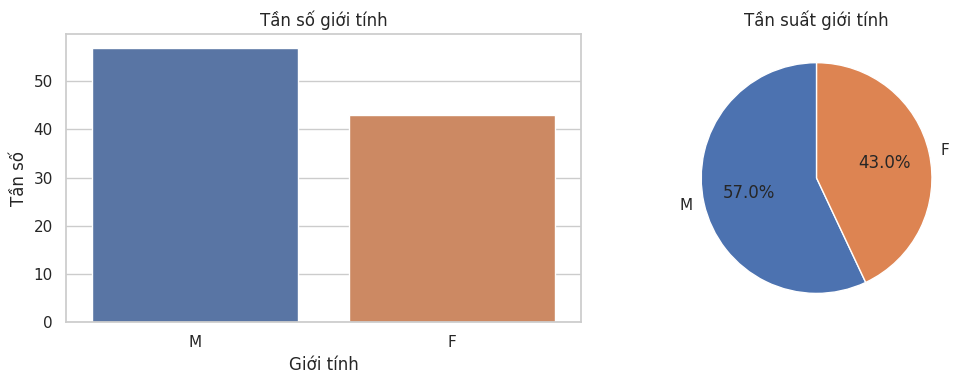

In [16]:
freq_gt = df2['GT'].value_counts().rename_axis('Giới tính').reset_index(name='Tần số')
freq_gt['Tần suất (%)'] = (freq_gt['Tần số'] / len(df2) * 100).round(2)
display(freq_gt)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=freq_gt, x='Giới tính', y='Tần số', hue='Giới tính', legend=False, ax=axes[0])
axes[0].set_title('Tần số giới tính')
axes[1].pie(freq_gt['Tần số'], labels=freq_gt['Giới tính'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Tần suất giới tính')
plt.tight_layout(); plt.show(); plt.close()

### 02. Phân bố US_TBM1, US_TBM2 và US_TBM3

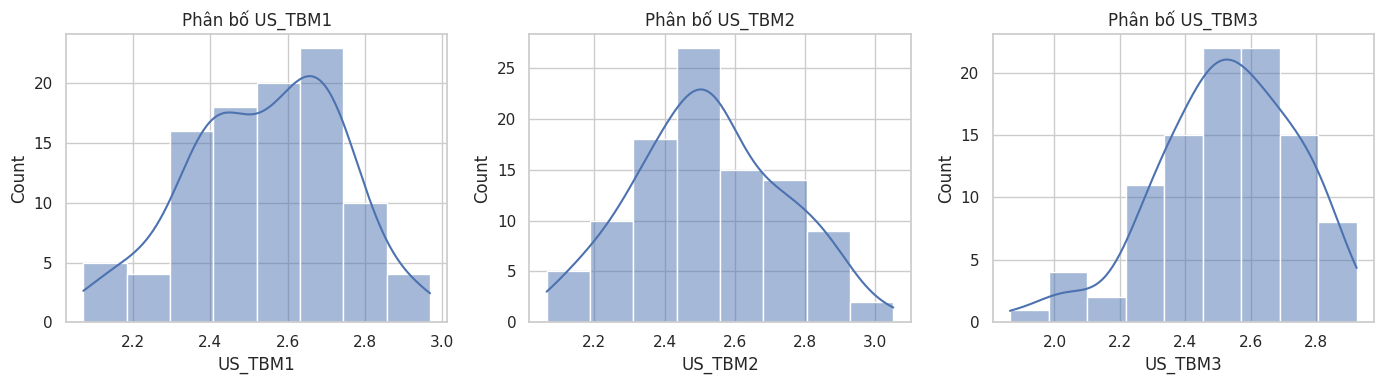

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['US_TBM1', 'US_TBM2', 'US_TBM3']):
    sns.histplot(df2[col], kde=True, color='C0', ax=ax)
    ax.set_title(f'Phân bố {col}')
plt.tight_layout(); plt.show(); plt.close()

### 03. Trình bày biến DT với học sinh nam

,Dân tộc,Tần số,Tần suất (%)
0,0.0,53,92.98
1,2.0,3,5.26
2,1.0,1,1.75


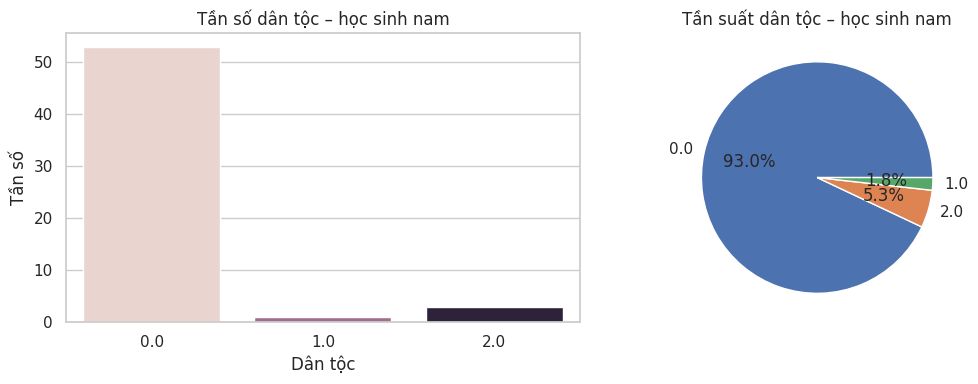

In [18]:
df_male = df2[df2['GT'] == 'M'].copy()
freq_dt_male = df_male['DT'].value_counts().rename_axis('Dân tộc').reset_index(name='Tần số')
freq_dt_male['Tần suất (%)'] = (freq_dt_male['Tần số'] / len(df_male) * 100).round(2)
display(freq_dt_male)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.barplot(data=freq_dt_male, x='Dân tộc', y='Tần số', hue='Dân tộc', legend=False, ax=axes[0])
axes[0].set_title('Tần số dân tộc – học sinh nam')
axes[1].pie(freq_dt_male['Tần số'], labels=freq_dt_male['Dân tộc'], autopct='%1.1f%%')
axes[1].set_title('Tần suất dân tộc – học sinh nam')
plt.tight_layout(); plt.show(); plt.close()

### 04. Trình bày KV của học sinh nam dân tộc Kinh và đủ điều kiện điểm

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
0,1,6.800000,5.9,6.9,8.9,6.1,8.4,7.1,8.0,5.2,7.0,6.3,8.0,4.5,6.5,8.1,5.6,6.3,4.8,6.3,5.6,5.7,6.8,5.6,5.7,5.8,7.2,5.6,7.6,6.0,5.6,8.2,4.9,5.6,7.2,7.0,6.0,7.8,6.3,5.9,7.3,6.8,7.2,5.2,5.8,6.3,4.2,7.5,7.5,M,0.0,2NT,A,6.00,6.00,6.00,7.10,6.09,5.88,K,TB,TB,2.840,2.436,2.352,1
1,2,4.900000,8.3,8.4,4.2,6.7,7.7,5.6,6.0,4.8,6.5,5.3,7.3,5.7,3.4,5.9,5.5,8.0,5.7,7.0,8.0,5.4,3.9,6.1,5.1,7.8,6.8,8.4,4.8,7.8,4.4,7.4,5.6,8.1,9.4,7.6,8.3,9.9,5.1,5.3,7.4,7.7,6.6,3.5,8.0,5.7,8.0,6.5,5.7,M,0.0,1,A1,5.50,5.00,5.00,6.34,5.49,6.26,TB,TB,TB,2.536,2.196,2.504,1
5,6,6.349485,6.1,6.3,4.9,6.0,5.6,7.2,5.0,8.0,9.4,6.9,7.4,5.4,2.8,7.4,7.1,8.4,9.2,3.6,4.7,8.0,5.7,6.0,5.7,4.0,7.7,5.1,6.1,6.6,6.5,5.7,6.5,5.9,7.1,4.6,8.8,7.6,6.1,2.6,9.9,6.0,7.5,6.0,6.4,8.2,8.7,6.7,7.2,M,0.0,1,A1,5.50,4.00,4.75,5.98,6.78,6.77,TB,K,K,2.392,2.712,2.708,0
19,20,6.300000,6.1,5.4,4.7,8.4,8.8,8.5,4.9,4.7,3.7,7.3,5.0,8.3,8.1,6.4,3.6,5.3,4.5,6.0,4.3,7.1,7.5,4.2,6.0,3.0,3.9,8.8,4.8,7.6,7.7,3.4,4.6,7.9,7.5,8.2,7.4,6.0,6.8,6.0,7.0,6.4,5.3,5.8,10.0,8.4,3.9,7.3,6.6,M,0.0,2NT,B,6.00,5.25,7.25,6.78,6.01,5.73,K,TB,TB,2.712,2.404,2.292,1
30,31,9.500000,5.8,4.3,8.6,4.9,5.9,8.7,7.0,7.0,6.4,8.1,5.1,5.6,3.7,6.0,7.2,4.6,6.3,7.5,3.9,8.3,6.5,7.1,5.1,4.2,8.1,6.5,4.7,5.1,5.3,6.3,7.4,5.7,6.4,4.1,8.7,7.5,5.3,5.0,4.9,4.6,7.9,8.1,9.1,6.3,7.7,3.8,6.2,M,0.0,2,A1,5.75,7.75,4.25,6.91,6.17,6.22,K,TB,TB,2.764,2.468,2.488,1


,Khu vực,Tần số,Tần suất (%)
0,1,9,39.13
1,2,9,39.13
2,2NT,5,21.74


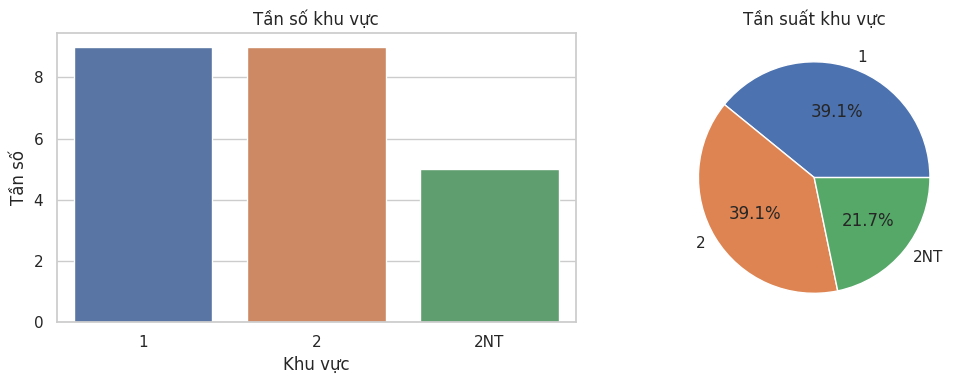

In [19]:
df_male_kinh_scores = df_male[
    (df_male['DT'] == 0.0) &
    (df_male['DH1'] >= 5.0) &
    (df_male['DH2'] >= 4.0) &
    (df_male['DH3'] >= 4.0)
].copy()

freq_kv = df_male_kinh_scores['KV'].value_counts().rename_axis('Khu vực').reset_index(name='Tần số')
freq_kv['Tần suất (%)'] = (freq_kv['Tần số'] / max(len(df_male_kinh_scores), 1) * 100).round(2)
display(df_male_kinh_scores.head())
display(freq_kv)

if not freq_kv.empty:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    sns.barplot(data=freq_kv, x='Khu vực', y='Tần số', hue='Khu vực', legend=False, ax=axes[0])
    axes[0].set_title('Tần số khu vực')
    axes[1].pie(freq_kv['Tần số'], labels=freq_kv['Khu vực'], autopct='%1.1f%%')
    axes[1].set_title('Tần suất khu vực')
    plt.tight_layout(); plt.show(); plt.close()

### 05. Phân bố DH1, DH2, DH3 của khu vực 2NT với điểm từ 5 trở lên

,STT,T1,L1,H1,S1,V1,X1,D1,N1,T2,L2,H2,S2,V2,X2,D2,N2,T3,L3,H3,S3,V3,X3,D3,N3,T4,L4,H4,S4,V4,X4,D4,N4,T5,L5,H5,S5,V5,X5,D5,N5,T6,L6,H6,S6,V6,X6,D6,N6,GT,DT,KV,KT,DH1,DH2,DH3,TBM1,TBM2,TBM3,XL1,XL2,XL3,US_TBM1,US_TBM2,US_TBM3,KQXT
0,1,6.800000,5.9,6.9,8.9,6.1,8.4,7.1,8.0,5.2,7.0,6.3,8.0,4.5,6.5,8.1,5.6,6.3,4.8,6.3,5.6,5.7,6.8,5.6,5.7,5.8,7.2,5.6,7.6,6.0,5.6,8.2,4.9,5.6,7.2,7.0,6.0,7.8,6.3,5.9,7.3,6.8,7.2,5.2,5.8,6.3,4.2,7.5,7.5,M,0.0,2NT,A,6.00,6.00,6.00,7.10,6.09,5.88,K,TB,TB,2.840,2.436,2.352,1
19,20,6.300000,6.1,5.4,4.7,8.4,8.8,8.5,4.9,4.7,3.7,7.3,5.0,8.3,8.1,6.4,3.6,5.3,4.5,6.0,4.3,7.1,7.5,4.2,6.0,3.0,3.9,8.8,4.8,7.6,7.7,3.4,4.6,7.9,7.5,8.2,7.4,6.0,6.8,6.0,7.0,6.4,5.3,5.8,10.0,8.4,3.9,7.3,6.6,M,0.0,2NT,B,6.00,5.25,7.25,6.78,6.01,5.73,K,TB,TB,2.712,2.404,2.292,1
25,26,6.349485,6.9,6.7,7.5,5.9,5.8,5.6,8.5,6.4,9.1,5.9,6.0,7.2,7.8,5.1,8.0,8.0,6.5,7.4,4.7,4.3,6.7,6.7,7.1,8.0,7.4,6.2,5.9,6.2,7.7,6.4,7.2,5.5,6.8,6.9,8.7,9.3,8.4,6.0,7.7,5.0,6.3,7.0,5.8,7.5,4.7,7.0,8.0,F,0.0,2NT,B,6.50,6.25,6.50,6.55,6.91,6.37,K,K,TB,2.620,2.764,2.548,1
52,53,4.300000,4.0,8.9,5.6,9.2,6.8,8.8,4.9,7.7,7.1,6.6,6.8,5.2,4.5,6.2,5.6,7.2,5.4,6.0,3.8,8.1,5.2,7.4,6.3,7.2,5.8,8.3,4.1,8.4,6.0,5.1,7.0,4.4,7.6,9.2,7.9,7.6,6.1,4.4,6.3,7.0,6.9,7.1,6.5,4.5,5.4,7.0,7.1,M,0.0,2NT,D1,6.75,7.25,5.25,6.60,6.26,6.47,K,TB,TB,2.640,2.504,2.588,1


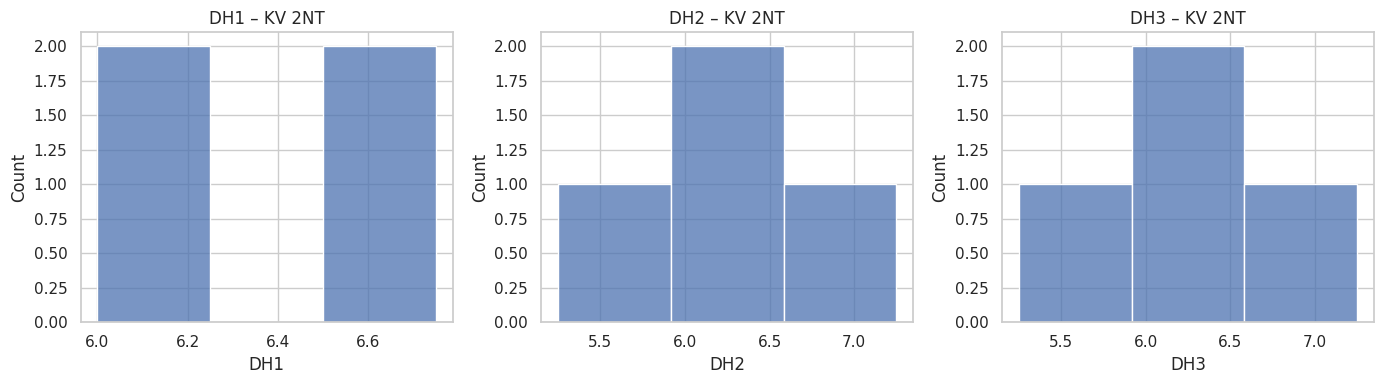

In [20]:
df_2nt = df2[
    (df2['KV'] == '2NT') &
    (df2['DH1'] >= 5) & (df2['DH2'] >= 5) & (df2['DH3'] >= 5)
]
display(df_2nt.head())

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['DH1', 'DH2', 'DH3']):
    sns.histplot(df_2nt[col], kde=False, color='C0', ax=ax)
    ax.set_title(f'{col} – KV 2NT')
plt.tight_layout(); plt.show(); plt.close()

## Phần 03: Trực quan hóa theo nhóm phân loại

### 01. Xếp loại XL1, XL2, XL3 của học sinh nữ

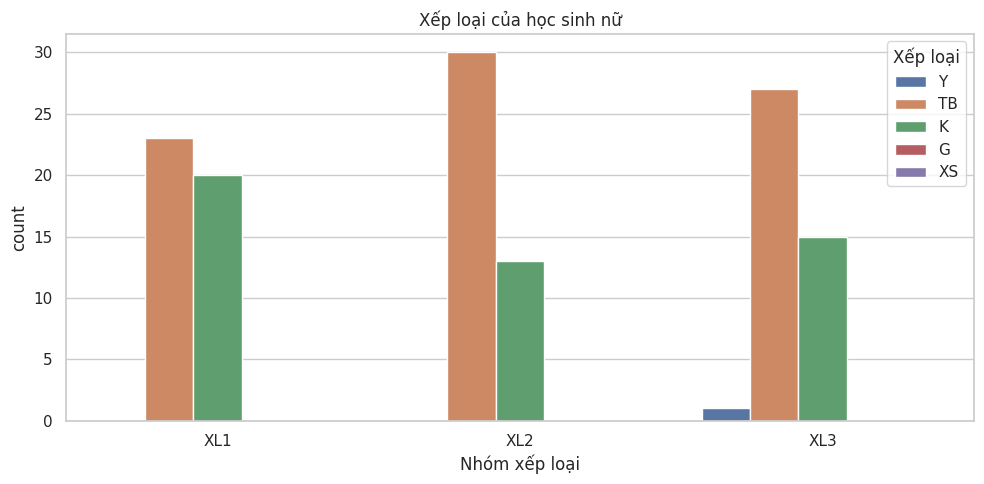

In [21]:
df_female_xl = df2[df2['GT'] == 'F'][['XL1', 'XL2', 'XL3']]
xl_long = df_female_xl.melt(var_name='Nhóm xếp loại', value_name='Xếp loại')
plt.figure(figsize=(10, 5))
sns.countplot(data=xl_long, x='Nhóm xếp loại', hue='Xếp loại', hue_order=['Y', 'TB', 'K', 'G', 'XS'])
plt.title('Xếp loại của học sinh nữ')
plt.tight_layout(); plt.show(); plt.close()

### 02. KQXT của khối A, A1, B thuộc khu vực 1 và 2

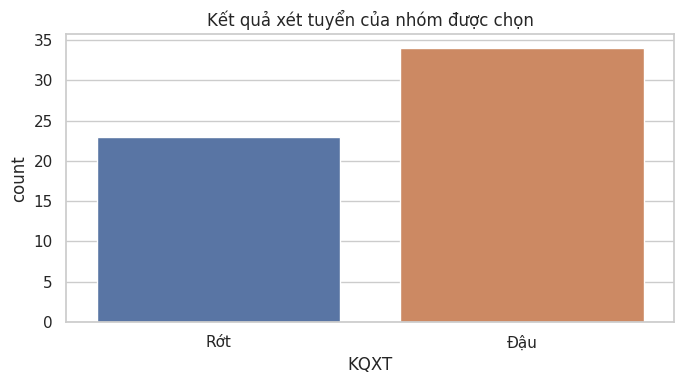

In [22]:
df_kq = df2[df2['KT'].isin(['A', 'A1', 'B']) & df2['KV'].isin(['1', '2'])]
plt.figure(figsize=(7, 4))
sns.countplot(data=df_kq, x='KQXT', hue='KQXT', legend=False)
plt.xticks([0, 1], ['Rớt', 'Đậu'])
plt.title('Kết quả xét tuyển của nhóm được chọn')
plt.tight_layout(); plt.show(); plt.close()

### 03. Số lượng thí sinh theo khối thi và khu vực

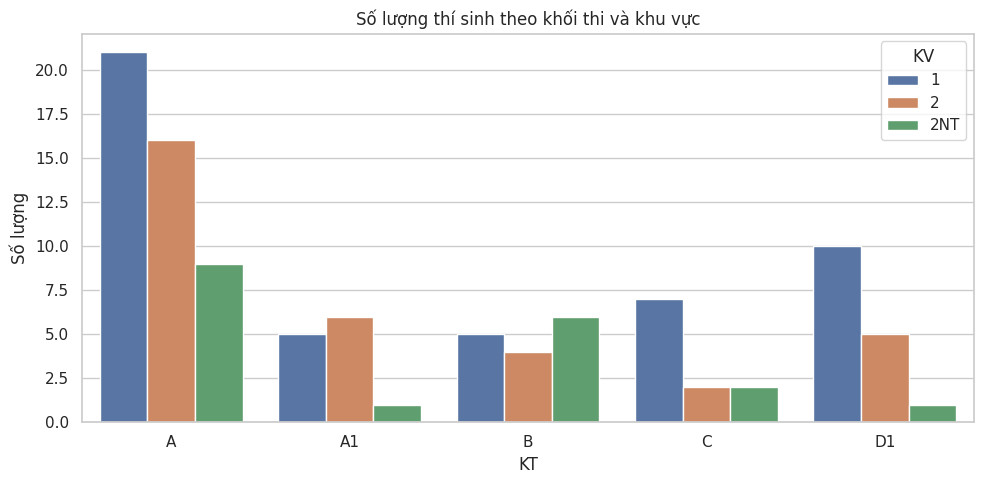

In [23]:
grouped_kt_kv = df2.groupby(['KT', 'KV']).size().reset_index(name='Số lượng')
plt.figure(figsize=(10, 5))
sns.barplot(data=grouped_kt_kv, x='KT', y='Số lượng', hue='KV')
plt.title('Số lượng thí sinh theo khối thi và khu vực')
plt.tight_layout(); plt.show(); plt.close()

### 04. Số lượng đậu và rớt theo khối thi, khu vực, dân tộc và giới tính

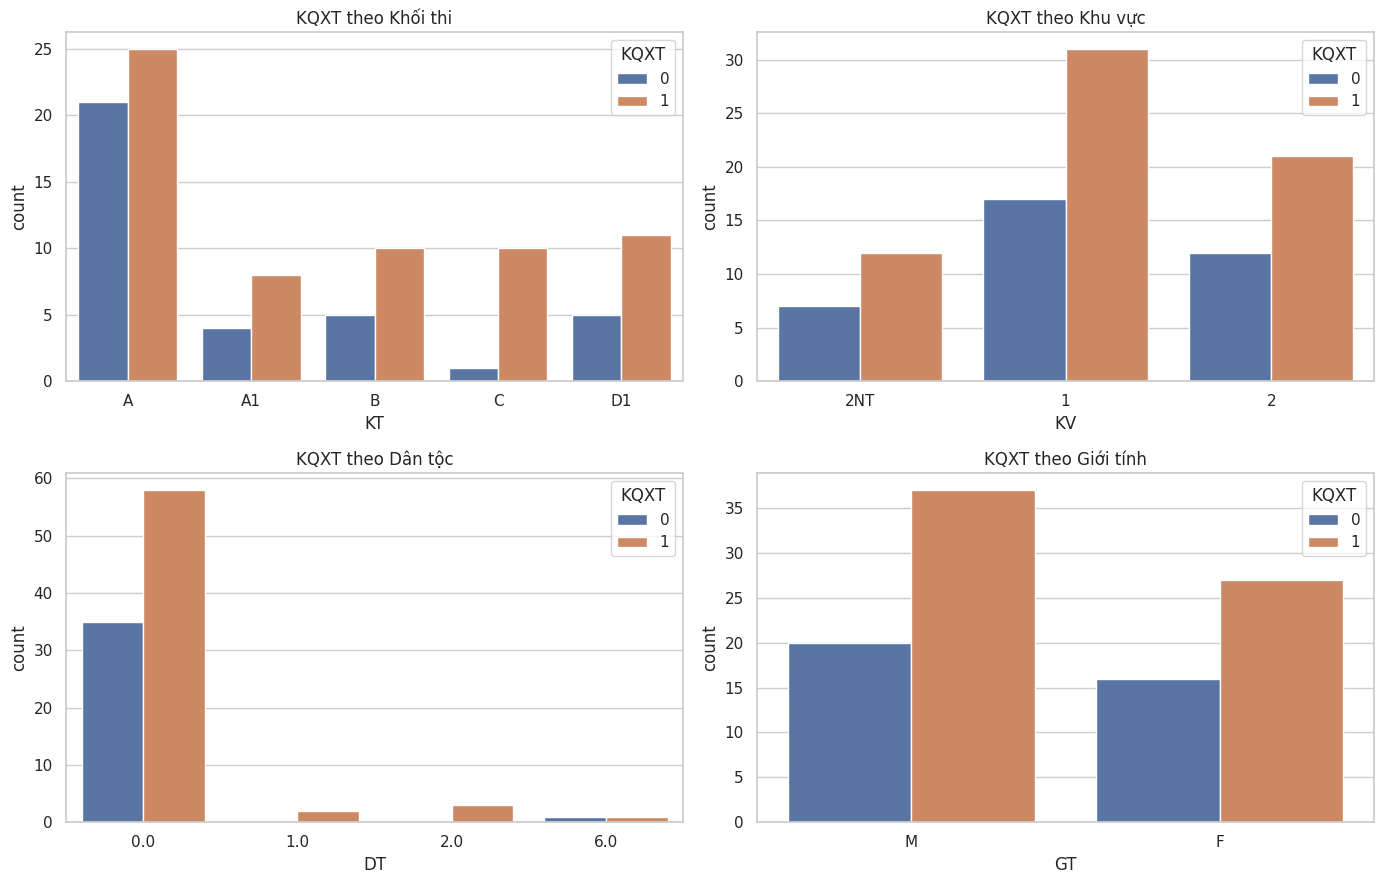

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, col, title in zip(
    axes.ravel(), ['KT', 'KV', 'DT', 'GT'],
    ['Khối thi', 'Khu vực', 'Dân tộc', 'Giới tính']
):
    sns.countplot(data=df2, x=col, hue='KQXT', ax=ax)
    ax.set_title(f'KQXT theo {title}')
plt.tight_layout(); plt.show(); plt.close()

## Phần 04: Trực quan hóa nâng cao

### 01. Biểu đồ đường của T1

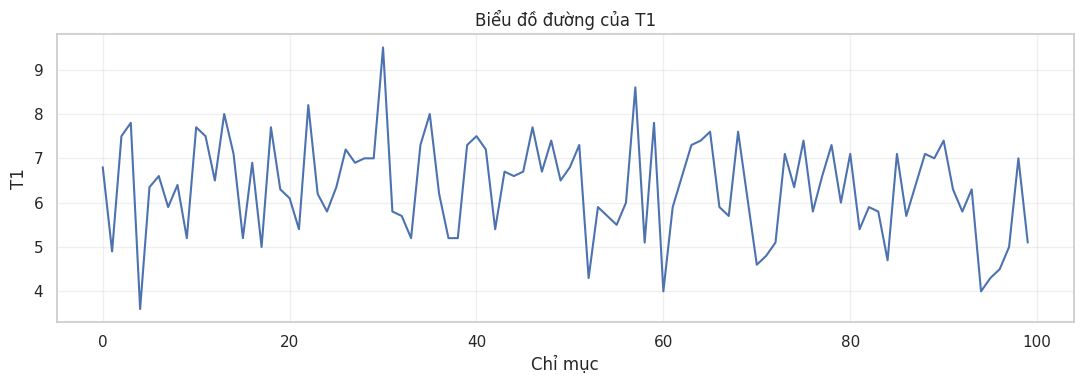

In [25]:
plt.figure(figsize=(11, 4))
sns.lineplot(x=df2.index, y=df2['T1'], color='C0')
plt.title('Biểu đồ đường của T1')
plt.xlabel('Chỉ mục'); plt.ylabel('T1'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show(); plt.close()

### 02. Tạo biến phân loại phanlopt1

In [26]:
def classify_t1(score):
    if score < 5:
        return 'kem'
    if score < 7:
        return 'trung_binh'
    if score < 8:
        return 'kha'
    return 'gioi'

df2['phanlopt1'] = df2['T1'].apply(classify_t1)
freq_t1 = df2['phanlopt1'].value_counts().rename_axis('Phân loại').reset_index(name='Tần số')
freq_t1['Tần suất (%)'] = (freq_t1['Tần số'] / len(df2) * 100).round(2)
display(freq_t1)

,Phân loại,Tần số,Tần suất (%)
0,trung_binh,55,55.0
1,kha,30,30.0
2,kem,10,10.0
3,gioi,5,5.0


### 03. Multiple line và drop-line của T1 theo phân loại

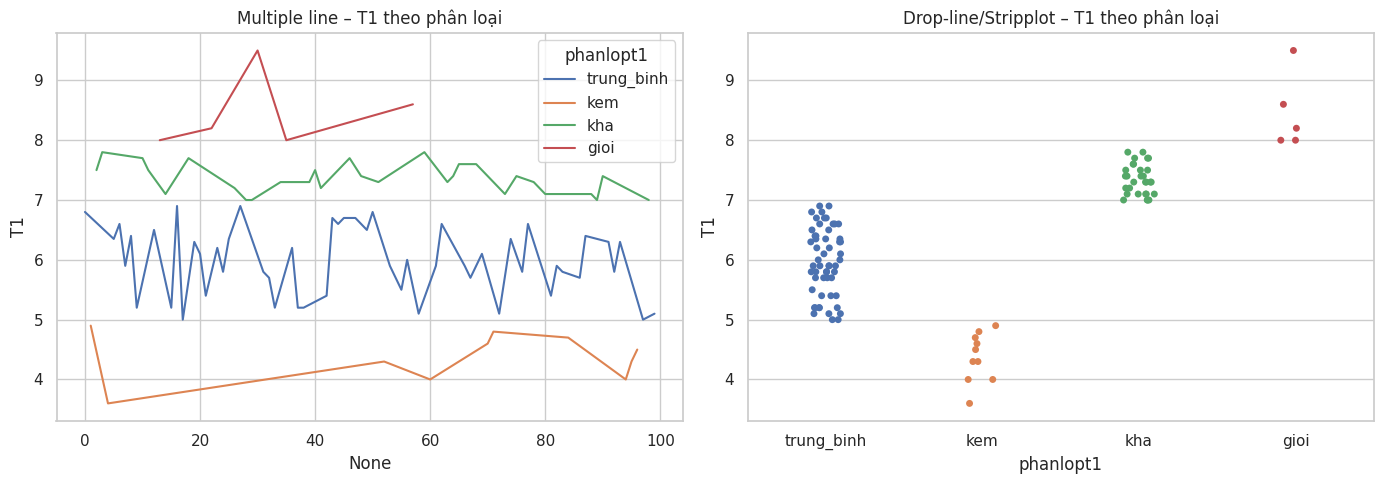

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=df2, x=df2.index, y='T1', hue='phanlopt1', ax=axes[0])
axes[0].set_title('Multiple line – T1 theo phân loại')
sns.stripplot(data=df2, x='phanlopt1', y='T1', hue='phanlopt1', legend=False, ax=axes[1])
axes[1].set_title('Drop-line/Stripplot – T1 theo phân loại')
plt.tight_layout(); plt.show(); plt.close()

### 04. Mô tả phân phối và tương quan

,T1
count,100.000000
mean,6.349485
std,1.105096
min,3.600000
25%,5.700000
50%,6.374742
75%,7.200000
max,9.500000


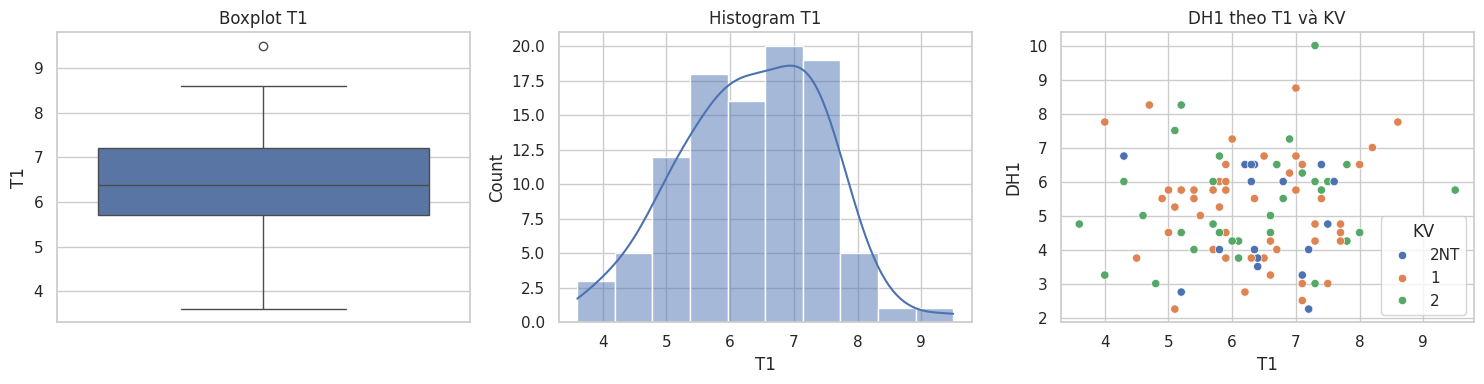

Hệ số tương quan T1–DH1: 0.0601


,DH1,DH2,DH3
DH1,1.0000,-0.1172,-0.0498
DH2,-0.1172,1.0000,0.1619
DH3,-0.0498,0.1619,1.0000


In [28]:
summary_t1 = df2['T1'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('T1')
display(summary_t1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df2['T1'], color='C0', ax=axes[0]); axes[0].set_title('Boxplot T1')
sns.histplot(df2['T1'], kde=True, color='C0', ax=axes[1]); axes[1].set_title('Histogram T1')
sns.scatterplot(data=df2, x='T1', y='DH1', hue='KV', ax=axes[2]); axes[2].set_title('DH1 theo T1 và KV')
plt.tight_layout(); plt.show(); plt.close()

print('Hệ số tương quan T1–DH1:', round(df2['T1'].corr(df2['DH1']), 4))
display(df2[['DH1', 'DH2', 'DH3']].corr().round(4))

# LAB 03: LÀM SẠCH DỮ LIỆU CƠ BẢN

## Phần 01: Chuẩn bị dữ liệu

### 01. Tạo hoặc nạp file patient_heart_rate.csv

In [29]:
heart_path = Path('patient_heart_rate.csv')
if not heart_path.exists():
    messy_rows = [
        '1,Mickéy Mousé,56,70kgs,72,69,71,-,-,-',
        '2,Donald Duck,34,154.89lbs,-,-,-,85,84,76',
        '3,Mini Mouse,16,110lbs,-,-,-,65,66,64',
        '4,Scrooge McDuck,65,85kgs,78,80,79,-,-,-',
        '5,Tom Cat,28,176lbs,90,88,86,-,-,-',
        '6,Jerry Mouse,20,45kgs,68,70,69,-,-,-',
        '7,Daisy Duck,,120lbs,-,-,-,74,75,73',
        '8,Goofy Dog,41,,82,80,81,-,-,-',
        '9,Pluto Dog,,,76,77,75,-,-,-',
        '10,Elsa Queen,25,55kgs,-,-,-,72,70,71',
        '11,Anna Queen,22,116lbs,-,-,-,78,77,76',
        '12,Olaf Snow,9,35kgs,95,93,94,-,-,-',
        '12,Olaf Snow,9,35kgs,95,93,94,-,-,-',
        '13,José Carioca,38,68kgs,75,-,77,-,-,-',
        ',,,,,,,,,',
        ',,,,,,,,,',
    ]
    heart_path.write_text('\n'.join(messy_rows), encoding='utf-8')
    print('Đã tạo dữ liệu y khoa lộn xộn dự phòng.')
else:
    print('Sử dụng patient_heart_rate.csv có sẵn.')

Sử dụng patient_heart_rate.csv có sẵn.


## Phần 02: Xử lý cấu trúc và định dạng

### 01. Thêm tiêu đề cột

In [30]:
column_names = ['Id', 'Name', 'Age', 'Weight', 'm0006', 'm0612', 'm1218', 'f0006', 'f0612', 'f1218']
heart_df = pd.read_csv(heart_path, names=column_names, encoding='utf-8-sig', on_bad_lines='skip')
print('Kích thước ban đầu:', heart_df.shape)
display(heart_df.head(10))

Kích thước ban đầu: (16, 10)


,Id,Name,Age,Weight,m0006,m0612,m1218,f0006,f0612,f1218
0,1.0,Mickéy Mousé,56.0,70kgs,72,69,71,-,-,-
1,2.0,Donald Duck,34.0,154.89lbs,-,-,-,85,84,76
2,3.0,Mini Mouse,16.0,110lbs,-,-,-,65,66,64
3,4.0,Scrooge McDuck,65.0,85kgs,78,80,79,-,-,-
4,5.0,Tom Cat,28.0,176lbs,90,88,86,-,-,-
5,6.0,Jerry Mouse,20.0,45kgs,68,70,69,-,-,-
6,7.0,Daisy Duck,NaN,120lbs,-,-,-,74,75,73
7,8.0,Goofy Dog,41.0,NaN,82,80,81,-,-,-
8,9.0,Pluto Dog,NaN,NaN,76,77,75,-,-,-
9,10.0,Elsa Queen,25.0,55kgs,-,-,-,72,70,71


### 02. Tách Name thành Firstname và Lastname

In [31]:
name_parts = heart_df['Name'].str.split(n=1, expand=True)
heart_df['Firstname'] = name_parts[0]
heart_df['Lastname'] = name_parts[1]
heart_df = heart_df.drop(columns='Name')
display(heart_df.head())

,Id,Age,Weight,m0006,m0612,m1218,f0006,f0612,f1218,Firstname,Lastname
0,1.0,56.0,70kgs,72,69,71,-,-,-,Mickéy,Mousé
1,2.0,34.0,154.89lbs,-,-,-,85,84,76,Donald,Duck
2,3.0,16.0,110lbs,-,-,-,65,66,64,Mini,Mouse
3,4.0,65.0,85kgs,78,80,79,-,-,-,Scrooge,McDuck
4,5.0,28.0,176lbs,90,88,86,-,-,-,Tom,Cat


### 03. Chuẩn hóa đơn vị Weight về kg

In [32]:
def normalize_weight(value):
    if pd.isna(value):
        return np.nan
    text = str(value).strip().lower()
    number = pd.to_numeric(re.sub(r'[^0-9.]', '', text), errors='coerce')
    if pd.isna(number):
        return np.nan
    if 'lbs' in text:
        number = number / 2.2
    return f'{int(round(number))}kgs'

heart_df['Weight'] = heart_df['Weight'].apply(normalize_weight)
display(heart_df.head(10))

,Id,Age,Weight,m0006,m0612,m1218,f0006,f0612,f1218,Firstname,Lastname
0,1.0,56.0,70kgs,72,69,71,-,-,-,Mickéy,Mousé
1,2.0,34.0,70kgs,-,-,-,85,84,76,Donald,Duck
2,3.0,16.0,50kgs,-,-,-,65,66,64,Mini,Mouse
3,4.0,65.0,85kgs,78,80,79,-,-,-,Scrooge,McDuck
4,5.0,28.0,80kgs,90,88,86,-,-,-,Tom,Cat
5,6.0,20.0,45kgs,68,70,69,-,-,-,Jerry,Mouse
6,7.0,NaN,55kgs,-,-,-,74,75,73,Daisy,Duck
7,8.0,41.0,NaN,82,80,81,-,-,-,Goofy,Dog
8,9.0,NaN,NaN,76,77,75,-,-,-,Pluto,Dog
9,10.0,25.0,55kgs,-,-,-,72,70,71,Elsa,Queen


## Phần 03: Loại bỏ dữ liệu lỗi

### 01. Xóa dòng rỗng và dòng trùng lặp

In [33]:
print('Trước khi xóa dòng rỗng:', len(heart_df))
heart_df = heart_df.dropna(how='all')
print('Sau khi xóa dòng rỗng:', len(heart_df))

before = len(heart_df)
heart_df = heart_df.drop_duplicates(subset=['Firstname', 'Lastname', 'Age', 'Weight'])
print('Số dòng trùng lặp đã xóa:', before - len(heart_df))

Trước khi xóa dòng rỗng: 16
Sau khi xóa dòng rỗng: 14
Số dòng trùng lặp đã xóa: 1


### 02. Loại ký tự non-ASCII

In [34]:
for col in ['Firstname', 'Lastname']:
    heart_df[col] = heart_df[col].replace({r'[^\x00-\x7F]+': ''}, regex=True)
display(heart_df)

,Id,Age,Weight,m0006,m0612,m1218,f0006,f0612,f1218,Firstname,Lastname
0,1.0,56.0,70kgs,72,69,71,-,-,-,Micky,Mous
1,2.0,34.0,70kgs,-,-,-,85,84,76,Donald,Duck
2,3.0,16.0,50kgs,-,-,-,65,66,64,Mini,Mouse
3,4.0,65.0,85kgs,78,80,79,-,-,-,Scrooge,McDuck
4,5.0,28.0,80kgs,90,88,86,-,-,-,Tom,Cat
5,6.0,20.0,45kgs,68,70,69,-,-,-,Jerry,Mouse
6,7.0,NaN,55kgs,-,-,-,74,75,73,Daisy,Duck
7,8.0,41.0,NaN,82,80,81,-,-,-,Goofy,Dog
8,9.0,NaN,NaN,76,77,75,-,-,-,Pluto,Dog
9,10.0,25.0,55kgs,-,-,-,72,70,71,Elsa,Queen


## Phần 04: Xử lý dữ liệu thiếu và chuyển dạng

### 01. Xử lý Age và Weight bị thiếu

In [35]:
display(heart_df[['Age', 'Weight']].isna().sum().to_frame('Số lượng thiếu'))
heart_df = heart_df.dropna(subset=['Age', 'Weight'], how='all').copy()
mean_age = heart_df['Age'].mean()
heart_df['Age'] = heart_df['Age'].fillna(round(mean_age, 1))
print('Mean Age dùng để điền:', round(mean_age, 2))
display(heart_df[['Age', 'Weight']].isna().sum().to_frame('Còn thiếu'))

,Số lượng thiếu
Age,2
Weight,2


Mean Age dùng để điền: 32.18


,Còn thiếu
Age,0
Weight,1


### 02. Melt các cột m0006...f1218 thành PulseRate, Sex và Time

In [36]:
heart_melted = pd.melt(
    heart_df,
    id_vars=['Id', 'Age', 'Weight', 'Firstname', 'Lastname'],
    var_name='sex_and_time', value_name='PulseRate'
)
extracted = heart_melted['sex_and_time'].str.extract(r'([mf])(\d{2})(\d{2})')
extracted.columns = ['Sex', 'hours_lower', 'hours_upper']
heart_melted['Sex'] = extracted['Sex']
heart_melted['Time'] = extracted['hours_lower'] + '-' + extracted['hours_upper']
heart_final = heart_melted.drop(columns='sex_and_time')
heart_final = heart_final[heart_final['PulseRate'].ne('-')].copy()
heart_final['PulseRate'] = pd.to_numeric(heart_final['PulseRate'], errors='coerce')
print('Kích thước sau khi melt:', heart_final.shape)
display(heart_final.head(15))

Kích thước sau khi melt: (35, 8)


,Id,Age,Weight,Firstname,Lastname,PulseRate,Sex,Time
0,1.0,56.0,70kgs,Micky,Mous,72,m,00-06
3,4.0,65.0,85kgs,Scrooge,McDuck,78,m,00-06
4,5.0,28.0,80kgs,Tom,Cat,90,m,00-06
5,6.0,20.0,45kgs,Jerry,Mouse,68,m,00-06
7,8.0,41.0,NaN,Goofy,Dog,82,m,00-06
10,12.0,9.0,35kgs,Olaf,Snow,95,m,00-06
11,13.0,38.0,68kgs,Jos,Carioca,75,m,00-06
12,1.0,56.0,70kgs,Micky,Mous,69,m,06-12
15,4.0,65.0,85kgs,Scrooge,McDuck,80,m,06-12
16,5.0,28.0,80kgs,Tom,Cat,88,m,06-12


### 03. Điền PulseRate thiếu theo thứ tự ưu tiên

In [37]:
def fill_pulse_rate(data):
    out = data.sort_values(['Id', 'Time']).reset_index(drop=True).copy()
    overall_mean = out['PulseRate'].mean()
    gender_mean = out.groupby('Sex')['PulseRate'].mean()

    for patient_id in out['Id'].dropna().unique():
        patient_idx = out.index[out['Id'] == patient_id].tolist()
        for local_pos, idx in enumerate(patient_idx):
            if pd.notna(out.loc[idx, 'PulseRate']):
                continue
            candidates = []
            if local_pos > 0:
                candidates.append(out.loc[patient_idx[local_pos - 1], 'PulseRate'])
            if local_pos < len(patient_idx) - 1:
                candidates.append(out.loc[patient_idx[local_pos + 1], 'PulseRate'])
            candidates = [v for v in candidates if pd.notna(v)]
            value = np.mean(candidates) if candidates else out.loc[patient_idx, 'PulseRate'].mean()
            if pd.isna(value):
                value = gender_mean.get(out.loc[idx, 'Sex'], np.nan)
            if pd.isna(value):
                value = overall_mean if pd.notna(overall_mean) else 75
            out.loc[idx, 'PulseRate'] = round(float(value), 1)
    return out

heart_final = fill_pulse_rate(heart_final)
print('PulseRate còn thiếu:', int(heart_final['PulseRate'].isna().sum()))

PulseRate còn thiếu: 0


## Phần 05: Hoàn thiện và lưu dữ liệu

### 01. Reindex và xuất patient_heart_rate_clean.csv

In [38]:
heart_clean = heart_final[['Id', 'Firstname', 'Lastname', 'Age', 'Weight', 'Sex', 'Time', 'PulseRate']]
heart_clean = heart_clean.sort_values(['Id', 'Sex', 'Time']).reset_index(drop=True)
heart_clean.to_csv('patient_heart_rate_clean.csv', index=False)
print('Kích thước dữ liệu sạch:', heart_clean.shape)
display(heart_clean)

Kích thước dữ liệu sạch: (35, 8)


,Id,Firstname,Lastname,Age,Weight,Sex,Time,PulseRate
0,1.0,Micky,Mous,56.0,70kgs,m,00-06,72
1,1.0,Micky,Mous,56.0,70kgs,m,06-12,69
2,1.0,Micky,Mous,56.0,70kgs,m,12-18,71
3,2.0,Donald,Duck,34.0,70kgs,f,00-06,85
4,2.0,Donald,Duck,34.0,70kgs,f,06-12,84
5,2.0,Donald,Duck,34.0,70kgs,f,12-18,76
6,3.0,Mini,Mouse,16.0,50kgs,f,00-06,65
7,3.0,Mini,Mouse,16.0,50kgs,f,06-12,66
8,3.0,Mini,Mouse,16.0,50kgs,f,12-18,64
9,4.0,Scrooge,McDuck,65.0,85kgs,m,00-06,78


# LAB 04: BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU

## Phần 01: Nạp và khảo sát dữ liệu Titanic

### 01. Khôi phục dữ liệu Titanic tích hợp

In [39]:
TITANIC_GZIP_B64 = '...'
titanic_path = Path('titanic_disaster.csv')
if not titanic_path.exists():
    titanic_path.write_bytes(gzip.decompress(base64.b64decode(TITANIC_GZIP_B64)))

titanic = pd.read_csv(titanic_path)
print('Kích thước:', titanic.shape)
display(titanic.head(10))

Kích thước: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


### 02. Thống kê và trực quan dữ liệu thiếu

,Số lượng thiếu,Tỉ lệ thiếu (%)
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


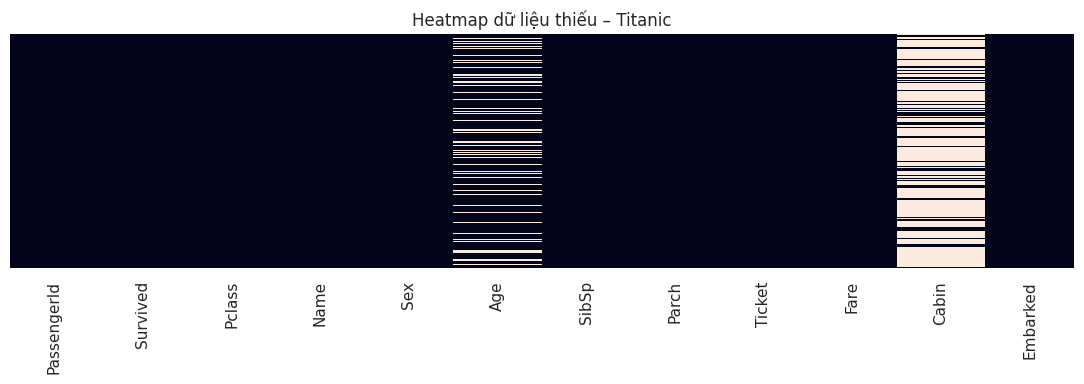

In [40]:
missing = titanic.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_table = pd.DataFrame({'Số lượng thiếu': missing, 'Tỉ lệ thiếu (%)': (missing / len(titanic) * 100).round(2)})
display(missing_table)

plt.figure(figsize=(11, 4))
sns.heatmap(titanic.isna(), cbar=False, yticklabels=False)
plt.title('Heatmap dữ liệu thiếu – Titanic')
plt.tight_layout(); plt.show(); plt.close()

## Phần 02: Data Cleansing và Feature Engineering

### 01. Tách Name thành firstName và secondName

In [41]:
name_split = titanic['Name'].str.split(',', n=1, expand=True)
titanic['secondName'] = name_split[0].str.strip()
titanic['firstName'] = name_split[1].str.strip()
display(titanic[['Name', 'firstName', 'secondName']].head())

,Name,firstName,secondName
0,"Braund, Mr. Owen Harris",Mr. Owen Harris,Braund
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs. John Bradley (Florence Briggs Thayer),Cumings
2,"Heikkinen, Miss. Laina",Miss. Laina,Heikkinen
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs. Jacques Heath (Lily May Peel),Futrelle
4,"Allen, Mr. William Henry",Mr. William Henry,Allen


### 02. Rút gọn Sex thành M và F

In [42]:
titanic['Sex'] = titanic['Sex'].map({'male': 'M', 'female': 'F'})
print(titanic['Sex'].value_counts())

Sex
M    577
F    314
Name: count, dtype: int64


### 03. Khảo sát và điền Age theo Pclass

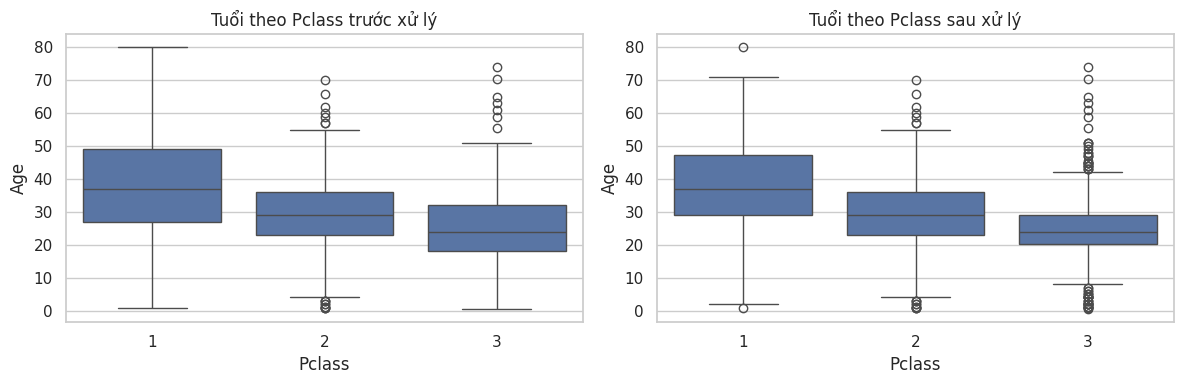

Age còn thiếu: 0


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=titanic, x='Pclass', y='Age', color='C0', ax=axes[0])
axes[0].set_title('Tuổi theo Pclass trước xử lý')

age_by_class = titanic.groupby('Pclass')['Age'].median()
for pclass, median_age in age_by_class.items():
    mask = (titanic['Pclass'] == pclass) & titanic['Age'].isna()
    titanic.loc[mask, 'Age'] = median_age

sns.boxplot(data=titanic, x='Pclass', y='Age', color='C0', ax=axes[1])
axes[1].set_title('Tuổi theo Pclass sau xử lý')
plt.tight_layout(); plt.show(); plt.close()
print('Age còn thiếu:', int(titanic['Age'].isna().sum()))

### 04. Tạo AgeGroup

In [44]:
titanic['AgeGroup'] = pd.cut(
    titanic['Age'], bins=[0, 12, 18, 60, np.inf],
    labels=['Kid', 'Teen', 'Adult', 'Older'], include_lowest=True
)
display(titanic['AgeGroup'].value_counts().sort_index().to_frame('count'))

,count
AgeGroup,
Kid,69
Teen,70
Adult,730
Older,22


### 05. Tách namePrefix và gom nhóm danh xưng hiếm

In [45]:
titanic['namePrefix'] = titanic['firstName'].str.extract(r'^([^\.]+)\.')[0].str.strip()
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
titanic['namePrefix'] = titanic['namePrefix'].where(titanic['namePrefix'].isin(common_titles), 'Other')
display(titanic['namePrefix'].value_counts().to_frame('count'))

,count
namePrefix,
Mr,517
Miss,182
Mrs,125
Master,40
Other,27


### 06. Tạo familySize và Alone

In [46]:
titanic['familySize'] = 1 + titanic['SibSp'] + titanic['Parch']
titanic['Alone'] = (titanic['familySize'] == 1).astype(int)
display(titanic['familySize'].value_counts().sort_index().to_frame('count'))
print(titanic['Alone'].value_counts().rename(index={0: 'Đi nhóm', 1: 'Đi một mình'}))

,count
familySize,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


Alone
Đi một mình    537
Đi nhóm        354
Name: count, dtype: int64


### 07. Tạo typeCabin

In [47]:
titanic['typeCabin'] = titanic['Cabin'].fillna('Unknown').str[0]
titanic.loc[titanic['Cabin'].isna(), 'typeCabin'] = 'Unknown'
display(titanic['typeCabin'].value_counts().to_frame('count'))

,count
typeCabin,
Unknown,687
C,59
B,47
D,33
E,32
A,15
F,13
G,4
T,1


## Phần 03: Phân tích khả năng sống sót

### 01. Sống sót theo giới tính và hạng vé

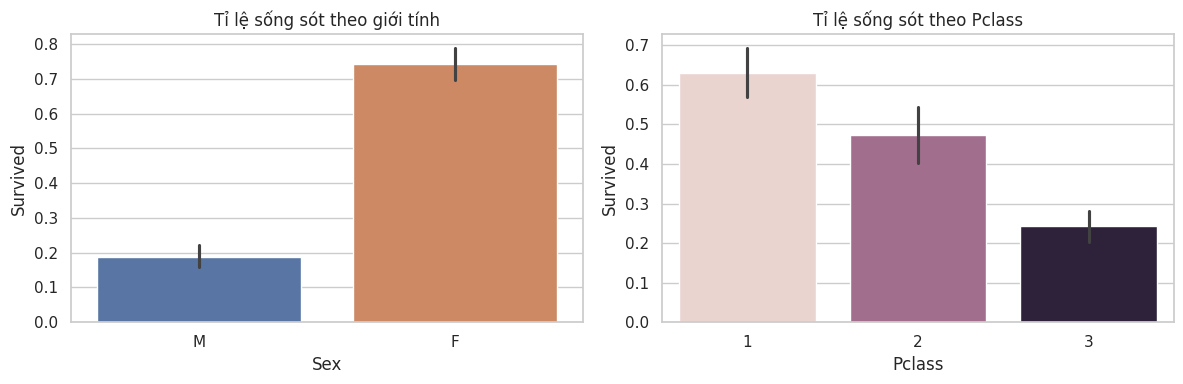

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=titanic, x='Sex', y='Survived', hue='Sex', legend=False, ax=axes[0])
axes[0].set_title('Tỉ lệ sống sót theo giới tính')
sns.barplot(data=titanic, x='Pclass', y='Survived', hue='Pclass', legend=False, ax=axes[1])
axes[1].set_title('Tỉ lệ sống sót theo Pclass')
plt.tight_layout(); plt.show(); plt.close()

### 02. Sống sót theo giới tính, nhóm tuổi và quy mô gia đình

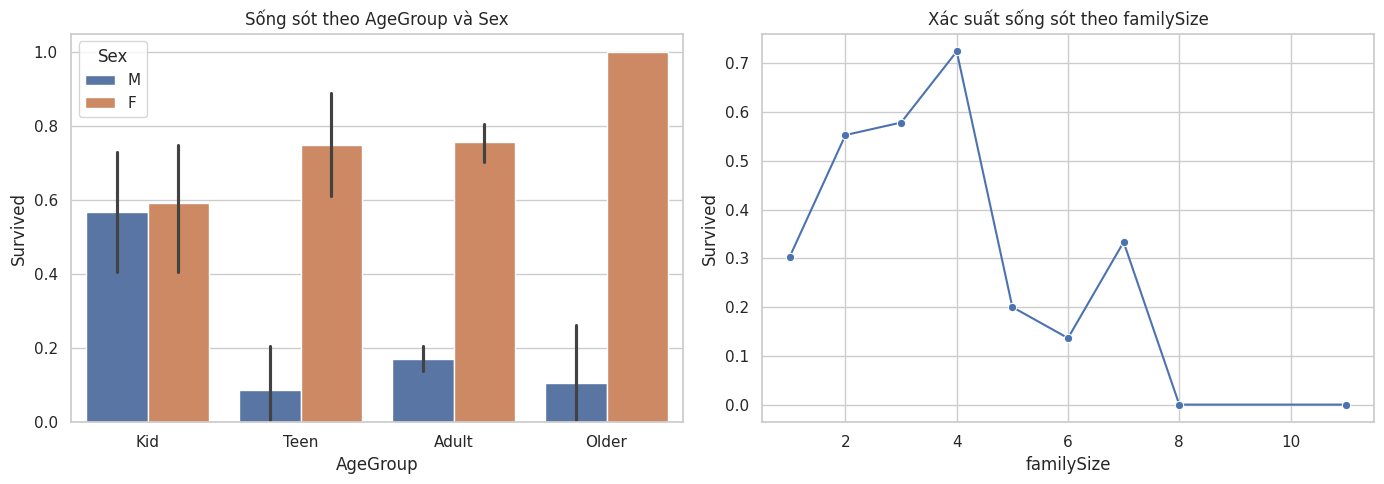

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=titanic, x='AgeGroup', y='Survived', hue='Sex', ax=axes[0])
axes[0].set_title('Sống sót theo AgeGroup và Sex')
sns.lineplot(data=titanic.groupby('familySize', as_index=False)['Survived'].mean(), x='familySize', y='Survived', marker='o', color='C0', ax=axes[1])
axes[1].set_title('Xác suất sống sót theo familySize')
plt.tight_layout(); plt.show(); plt.close()

### 03. Sống sót theo giá vé và cảng khởi hành

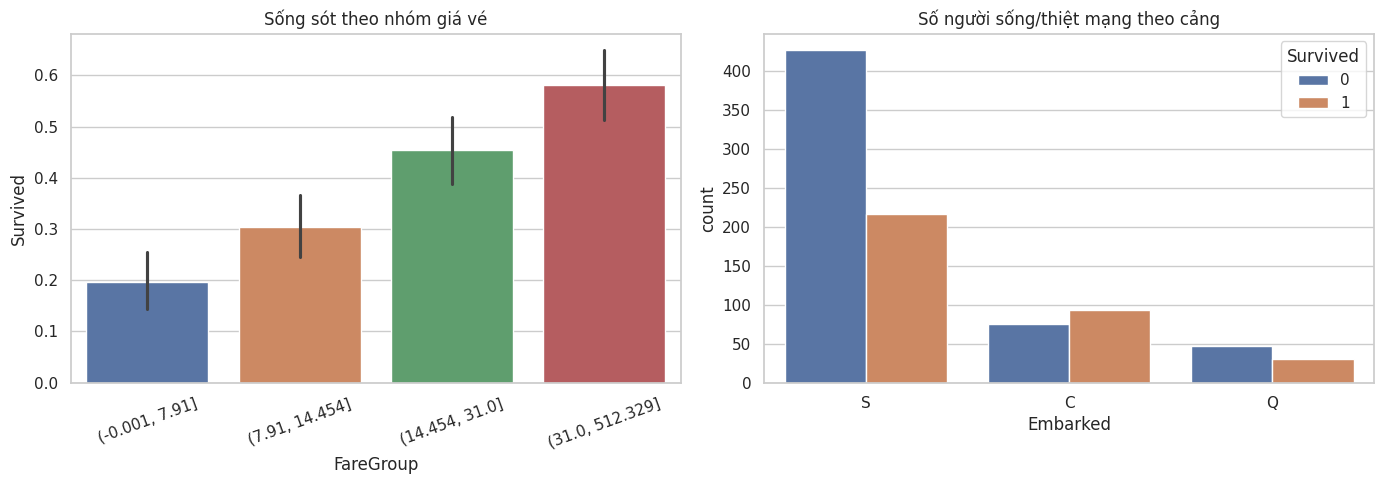

In [50]:
titanic['FareGroup'] = pd.qcut(titanic['Fare'], q=4, duplicates='drop')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=titanic, x='FareGroup', y='Survived', hue='FareGroup', legend=False, ax=axes[0])
axes[0].tick_params(axis='x', rotation=20)
axes[0].set_title('Sống sót theo nhóm giá vé')
sns.countplot(data=titanic, x='Embarked', hue='Survived', ax=axes[1])
axes[1].set_title('Số người sống/thiệt mạng theo cảng')
plt.tight_layout(); plt.show(); plt.close()

### 04. Ma trận tương quan các đặc trưng số

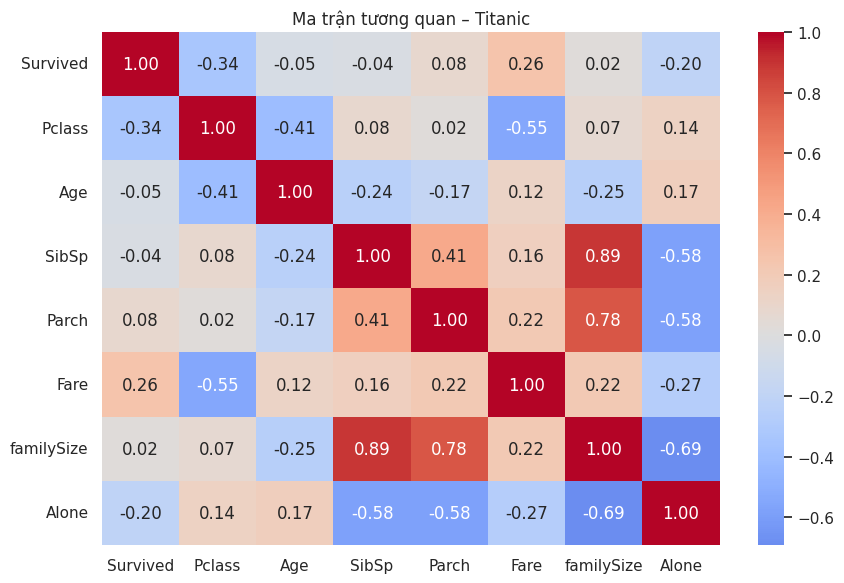

In [51]:
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'familySize', 'Alone']
corr = titanic[numeric_cols].corr()
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan – Titanic')
plt.tight_layout(); plt.show(); plt.close()

# LAB 05: BÀI THỰC HÀNH MẠNG NƠ-RON CƠ BẢN VỚI FASHION-MNIST

## Phần 01: Chuẩn bị dữ liệu

### 01. Khôi phục bộ mẫu Fashion-MNIST tích hợp

Bộ mẫu gồm 100 ảnh thật, cân bằng 10 lớp, được trích từ kết quả trực quan hóa của Lab 06. Notebook tạo thêm biến thể dịch chuyển và nhiễu nhẹ để thực hành huấn luyện hoàn toàn offline.

In [52]:
FASHION_SAMPLE_B64 = '...'
fashion_npz = np.load(io.BytesIO(base64.b64decode(FASHION_SAMPLE_B64)))
fashion_base_images = fashion_npz['images']
fashion_base_labels = fashion_npz['labels'].astype(np.int64)
fashion_class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
print('Bộ mẫu cơ sở:', fashion_base_images.shape)

Bộ mẫu cơ sở: (100, 28, 28)


In [53]:
def augment_fashion(images, labels, copies_per_image=8, seed=42):
    rng = np.random.default_rng(seed)
    X, y = [], []
    for image, label in zip(images, labels):
        for _ in range(copies_per_image):
            sample = image.astype(np.float32) / 255.0
            dy, dx = rng.integers(-1, 2, size=2)
            sample = np.roll(np.roll(sample, dy, axis=0), dx, axis=1)
            if dy > 0: sample[:dy, :] = 0
            if dy < 0: sample[dy:, :] = 0
            if dx > 0: sample[:, :dx] = 0
            if dx < 0: sample[:, dx:] = 0
            sample = np.clip(sample * rng.uniform(0.92, 1.08) + rng.normal(0, 0.02, sample.shape), 0, 1)
            X.append(sample)
            y.append(label)
    order = rng.permutation(len(X))
    return np.asarray(X, dtype=np.float32)[order], np.asarray(y, dtype=np.int64)[order]

train_base = np.concatenate([fashion_base_images[i*10:i*10+8] for i in range(10)])
train_base_y = np.concatenate([fashion_base_labels[i*10:i*10+8] for i in range(10)])
val_base = np.concatenate([fashion_base_images[i*10+8:i*10+10] for i in range(10)])
val_base_y = np.concatenate([fashion_base_labels[i*10+8:i*10+10] for i in range(10)])

X_train_fashion, y_train_fashion = augment_fashion(train_base, train_base_y, copies_per_image=8, seed=42)
X_val_fashion, y_val_fashion = augment_fashion(val_base, val_base_y, copies_per_image=8, seed=43)
print('Train:', X_train_fashion.shape, 'Validation:', X_val_fashion.shape)

Train: (640, 28, 28) Validation: (160, 28, 28)


### 02. Trực quan 10 lớp dữ liệu

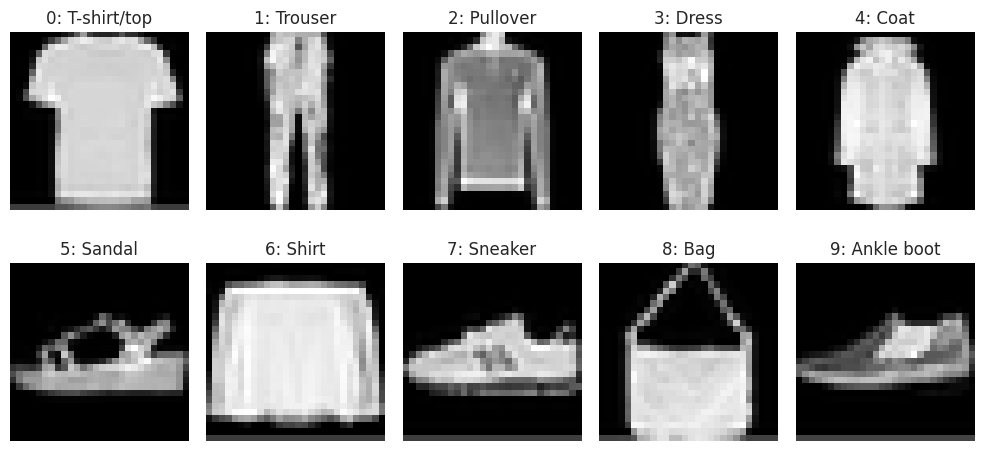

In [54]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for label, ax in enumerate(axes.ravel()):
    index = np.where(fashion_base_labels == label)[0][0]
    ax.imshow(fashion_base_images[index], cmap='gray')
    ax.set_title(f'{label}: {fashion_class_names[label]}')
    ax.axis('off')
plt.tight_layout(); plt.show(); plt.close()

## Phần 02: Huấn luyện với chuẩn hóa

### 01. Xây dựng Dataset, DataLoader và mô hình cơ bản

In [55]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam, SGD

torch.manual_seed(SEED)
torch.set_num_threads(1)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Thiết bị:', device)

def make_loaders(batch_size=64):
    train_ds = TensorDataset(torch.from_numpy(X_train_fashion).view(-1, 784), torch.from_numpy(y_train_fashion))
    val_ds = TensorDataset(torch.from_numpy(X_val_fashion).view(-1, 784), torch.from_numpy(y_val_fashion))
    return (
        DataLoader(train_ds, batch_size=batch_size, shuffle=True),
        DataLoader(val_ds, batch_size=256, shuffle=False)
    )

def build_basic_model(hidden=64):
    return nn.Sequential(nn.Linear(784, hidden), nn.ReLU(), nn.Linear(hidden, 10)).to(device)

def run_training(batch_size=64, optimizer_name='Adam', lr=0.003, epochs=3, hidden=64):
    train_loader, val_loader = make_loaders(batch_size)
    model = build_basic_model(hidden)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr) if optimizer_name == 'Adam' else SGD(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for _ in range(epochs):
        model.train(); running = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward(); optimizer.step()
            running.append(loss.item())

        model.eval(); total_loss = total_correct = total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                total_loss += loss_fn(logits, yb).item() * len(yb)
                total_correct += (logits.argmax(1) == yb).sum().item()
                total += len(yb)
        history['train_loss'].append(float(np.mean(running)))
        history['val_loss'].append(total_loss / total)
        history['val_acc'].append(total_correct / total)
    return model, history

basic_model, basic_history = run_training()
display(pd.DataFrame(basic_history, index=np.arange(1, 4)).rename_axis('Epoch').round(4))

Thiết bị: cpu


,train_loss,val_loss,val_acc
Epoch,,,
1,1.9904,1.5705,0.6062
2,1.2747,1.1783,0.6250
3,0.9075,1.1856,0.6250


### 02. Biểu đồ Loss và Accuracy

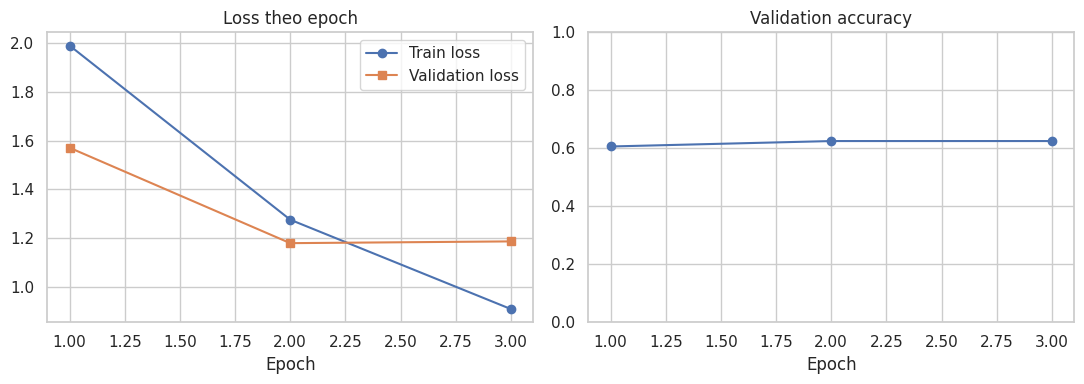

In [56]:
epochs = np.arange(1, len(basic_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(epochs, basic_history['train_loss'], marker='o', label='Train loss')
axes[0].plot(epochs, basic_history['val_loss'], marker='s', label='Validation loss')
axes[0].legend(); axes[0].set_title('Loss theo epoch'); axes[0].set_xlabel('Epoch')
axes[1].plot(epochs, basic_history['val_acc'], marker='o')
axes[1].set_title('Validation accuracy'); axes[1].set_xlabel('Epoch'); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show(); plt.close()

## Phần 03: So sánh Batch Size

### 01. Huấn luyện với Batch Size 32, 64 và 128

In [57]:
batch_results = {}
for bs in [32, 64, 128]:
    _, hist = run_training(batch_size=bs, epochs=2)
    batch_results[bs] = hist

batch_summary = pd.DataFrame({bs: hist['val_acc'][-1] for bs, hist in batch_results.items()}, index=['Validation Accuracy']).T
batch_summary.index.name = 'Batch Size'
display(batch_summary.round(4))

,Validation Accuracy
Batch Size,
32,0.6562
64,0.5000
128,0.5438


## Phần 04: So sánh Optimizer

### 01. So sánh SGD và Adam

In [58]:
optimizer_results = {}
for name, lr in [('SGD', 0.05), ('Adam', 0.003)]:
    _, hist = run_training(optimizer_name=name, lr=lr, epochs=2)
    optimizer_results[name] = hist

display(pd.DataFrame({name: hist['val_acc'][-1] for name, hist in optimizer_results.items()}, index=['Validation Accuracy']).T.round(4))

,Validation Accuracy
SGD,0.4125
Adam,0.5938


## Phần 05: So sánh Learning Rate

### 01. Thử các Learning Rate khác nhau với Adam

In [59]:
lr_results = {}
for lr in [0.01, 0.003, 0.001]:
    _, hist = run_training(optimizer_name='Adam', lr=lr, epochs=2)
    lr_results[lr] = hist

lr_summary = pd.DataFrame({lr: hist['val_acc'][-1] for lr, hist in lr_results.items()}, index=['Validation Accuracy']).T
lr_summary.index.name = 'Learning Rate'
display(lr_summary.round(4))

,Validation Accuracy
Learning Rate,
0.010,0.5312
0.003,0.6125
0.001,0.6125


# LAB 06: XÂY DỰNG MẠNG NƠ-RON SÂU (DEEP NEURAL NETWORK)

## Phần 01: Xây dựng kiến trúc mạng sâu

### 01. Định nghĩa DeepNeuralNetwork

In [60]:
class DeepNeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(784, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.15),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

deep_model = DeepNeuralNetwork().to(device)
print(deep_model)
print('Tổng số tham số:', sum(p.numel() for p in deep_model.parameters()))

DeepNeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.15, inplace=False)
    (7): Linear(in_features=128, out_features=64, bias=True)
    (8): ReLU()
    (9): Linear(in_features=64, out_features=10, bias=True)
  )
)
Tổng số tham số: 243274


## Phần 02: Huấn luyện mô hình

### 01. Hàm train và evaluate

In [61]:
def train_deep_model(model, epochs=6, batch_size=64, lr=0.002):
    train_loader, val_loader = make_loaders(batch_size)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(1, epochs + 1):
        model.train(); loss_sum = correct = total = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward(); optimizer.step()
            loss_sum += loss.item() * len(yb)
            correct += (logits.argmax(1) == yb).sum().item(); total += len(yb)

        model.eval(); val_loss_sum = val_correct = val_total = 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                val_loss_sum += loss_fn(logits, yb).item() * len(yb)
                val_correct += (logits.argmax(1) == yb).sum().item(); val_total += len(yb)

        history['train_loss'].append(loss_sum / total)
        history['train_acc'].append(correct / total)
        history['val_loss'].append(val_loss_sum / val_total)
        history['val_acc'].append(val_correct / val_total)
        print(f'Epoch {epoch:02d}: train_acc={correct/total:.3f}, val_acc={val_correct/val_total:.3f}')
    return history

deep_history = train_deep_model(deep_model)

Epoch 01: train_acc=0.444, val_acc=0.306
Epoch 02: train_acc=0.709, val_acc=0.581
Epoch 03: train_acc=0.823, val_acc=0.556
Epoch 04: train_acc=0.914, val_acc=0.531
Epoch 05: train_acc=0.944, val_acc=0.600
Epoch 06: train_acc=0.959, val_acc=0.556


## Phần 03: Đánh giá quá trình học

### 01. Vẽ Loss và Accuracy

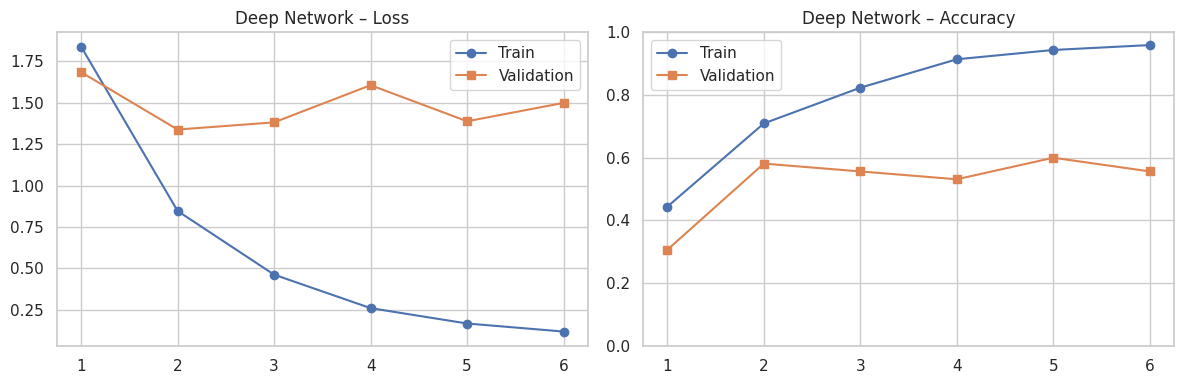

In [62]:
epochs = np.arange(1, len(deep_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs, deep_history['train_loss'], marker='o', label='Train')
axes[0].plot(epochs, deep_history['val_loss'], marker='s', label='Validation')
axes[0].set_title('Deep Network – Loss'); axes[0].legend()
axes[1].plot(epochs, deep_history['train_acc'], marker='o', label='Train')
axes[1].plot(epochs, deep_history['val_acc'], marker='s', label='Validation')
axes[1].set_title('Deep Network – Accuracy'); axes[1].legend(); axes[1].set_ylim(0, 1)
plt.tight_layout(); plt.show(); plt.close()

## Phần 04: Confusion Matrix và Classification Report

### 01. Dự đoán tập validation

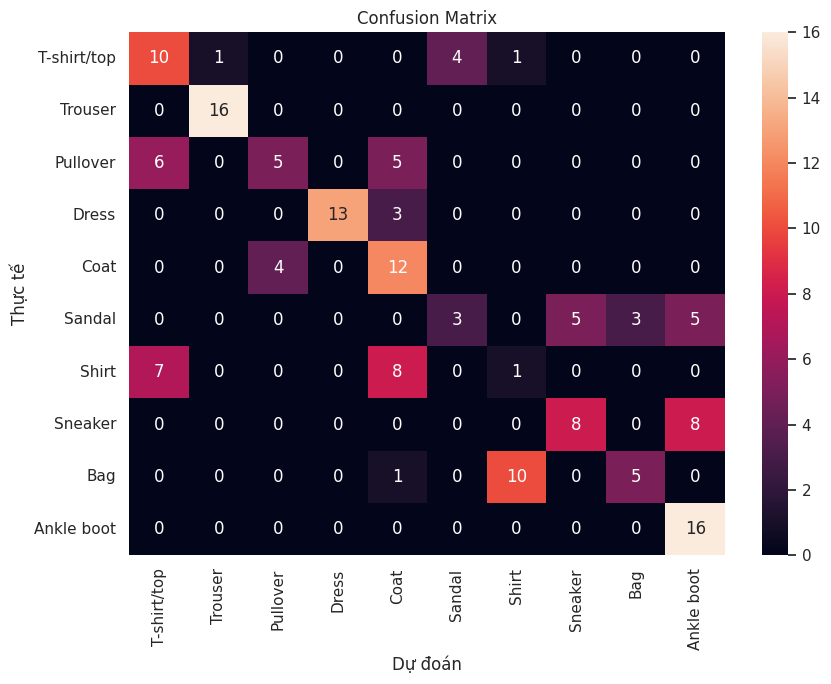

,precision,recall,f1-score,support
T-shirt/top,0.435,0.625,0.513,16.000
Trouser,0.941,1.000,0.970,16.000
Pullover,0.556,0.312,0.400,16.000
Dress,1.000,0.812,0.897,16.000
Coat,0.414,0.750,0.533,16.000
Sandal,0.429,0.188,0.261,16.000
Shirt,0.083,0.062,0.071,16.000
Sneaker,0.615,0.500,0.552,16.000
Bag,0.625,0.312,0.417,16.000
Ankle boot,0.552,1.000,0.711,16.000


In [63]:
from sklearn.metrics import confusion_matrix, classification_report

_, val_loader = make_loaders(64)
deep_model.eval(); y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in val_loader:
        pred = deep_model(xb.to(device)).argmax(1).cpu().numpy()
        y_true.extend(yb.numpy()); y_pred.extend(pred)

y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
cm = confusion_matrix(y_true, y_pred, labels=np.arange(10))
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=fashion_class_names, yticklabels=fashion_class_names)
plt.xlabel('Dự đoán'); plt.ylabel('Thực tế'); plt.title('Confusion Matrix')
plt.tight_layout(); plt.show(); plt.close()

report = classification_report(y_true, y_pred, target_names=fashion_class_names, zero_division=0, output_dict=True)
display(pd.DataFrame(report).T.round(3))

## Phần 05: Trực quan dự đoán

### 01. Hiển thị ảnh, nhãn thật và nhãn dự đoán

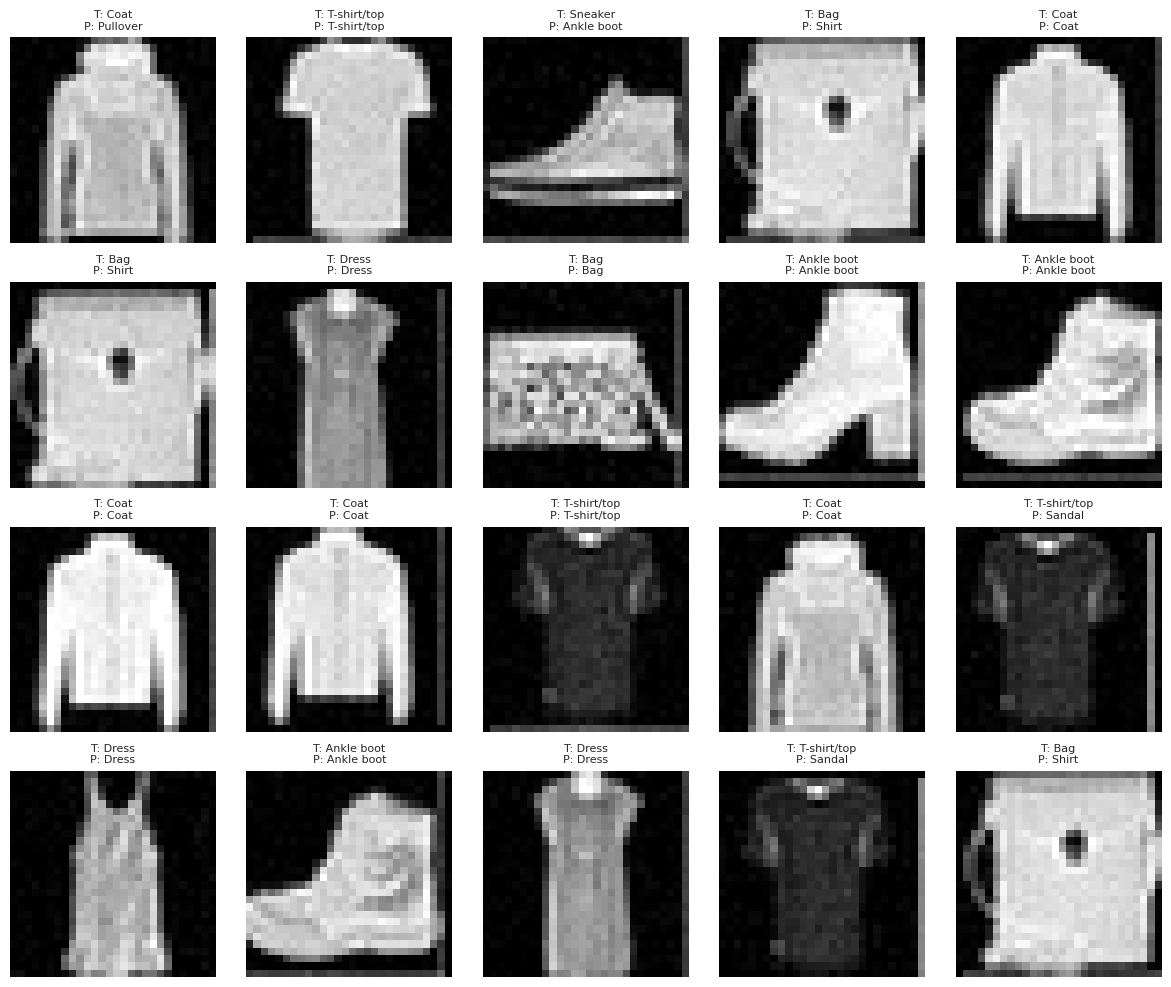

In [64]:
indices = np.linspace(0, len(X_val_fashion) - 1, 20, dtype=int)
with torch.no_grad():
    logits = deep_model(torch.from_numpy(X_val_fashion[indices]).view(-1, 784).to(device))
    preds = logits.argmax(1).cpu().numpy()

fig, axes = plt.subplots(4, 5, figsize=(12, 10))
for ax, idx, pred in zip(axes.ravel(), indices, preds):
    true = y_val_fashion[idx]
    ax.imshow(X_val_fashion[idx], cmap='gray')
    ax.set_title(f'T: {fashion_class_names[true]}\nP: {fashion_class_names[pred]}', fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show(); plt.close()

## Phần 06: So sánh và lưu mô hình

### 01. So sánh mạng cơ bản và mạng sâu

In [65]:
comparison = pd.DataFrame({
    'Mô hình': ['Basic Neural Network', 'Deep Neural Network'],
    'Validation Accuracy': [basic_history['val_acc'][-1], deep_history['val_acc'][-1]]
})
display(comparison.round(4))

model_path = Path('fashion_dnn_model.pt')
torch.save({
    'model_state_dict': deep_model.state_dict(),
    'class_names': fashion_class_names,
    'input_shape': [28, 28]
}, model_path)
print(f'Đã lưu mô hình: {model_path} – {model_path.stat().st_size:,} bytes')

,Mô hình,Validation Accuracy
0,Basic Neural Network,0.6250
1,Deep Neural Network,0.5562


Đã lưu mô hình: fashion_dnn_model.pt – 980,602 bytes


# LAB 07: PHÂN TÍCH DỮ LIỆU DẠNG VĂN BẢN VỚI NLTK

## Phần 01: Chuẩn bị dữ liệu văn bản

### 01. Import NLTK và tạo văn bản mẫu offline

Phần này sử dụng các thuật toán của NLTK nhưng tích hợp sẵn văn bản và từ điển nhỏ, tránh phụ thuộc thao tác tải corpus khi nộp bài.

In [66]:
import nltk
from nltk import FreqDist, bigrams, trigrams
from nltk.tokenize import wordpunct_tokenize
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures

macbeth_text = """
Fair is foul, and foul is fair. Hover through the fog and filthy air.
When shall we three meet again, in thunder, lightning, or in rain?
All the world's a stage, and all the men and women merely players.
Tomorrow, and tomorrow, and tomorrow creeps in this petty pace from day to day.
Out, out, brief candle! Life's but a walking shadow, a poor player that struts and frets his hour upon the stage.
The brave Macbeth seeks power, yet ambition brings fear, doubt, and sorrow.
"""
macbeth_tokens = wordpunct_tokenize(macbeth_text)
macbeth_words = [w.lower() for w in macbeth_tokens if w.isalpha()]
print('Số token:', len(macbeth_tokens), '| Số từ chữ cái:', len(macbeth_words))
print('20 token đầu:', macbeth_tokens[:20])

Số token: 111 | Số từ chữ cái: 88
20 token đầu: ['Fair', 'is', 'foul', ',', 'and', 'foul', 'is', 'fair', '.', 'Hover', 'through', 'the', 'fog', 'and', 'filthy', 'air', '.', 'When', 'shall', 'we']


## Phần 02: Tìm từ và phân tích tần số

### 01. Tìm ngữ cảnh của từ stage

In [67]:
def concordance_lines(tokens, target, width=5):
    positions = [i for i, token in enumerate(tokens) if token.lower() == target.lower()]
    return [' '.join(tokens[max(0, i-width): i+width+1]) for i in positions]

for line in concordance_lines(macbeth_tokens, 'stage'):
    print('-', line)

- the world ' s a stage , and all the men
- frets his hour upon the stage . The brave Macbeth seeks


### 02. Tần số từ, stopwords và dấu câu

,Từ,Tần số
0,tomorrow,3
1,fair,2
2,foul,2
3,all,2
4,s,2
5,stage,2
6,day,2
7,out,2
8,hover,1
9,through,1


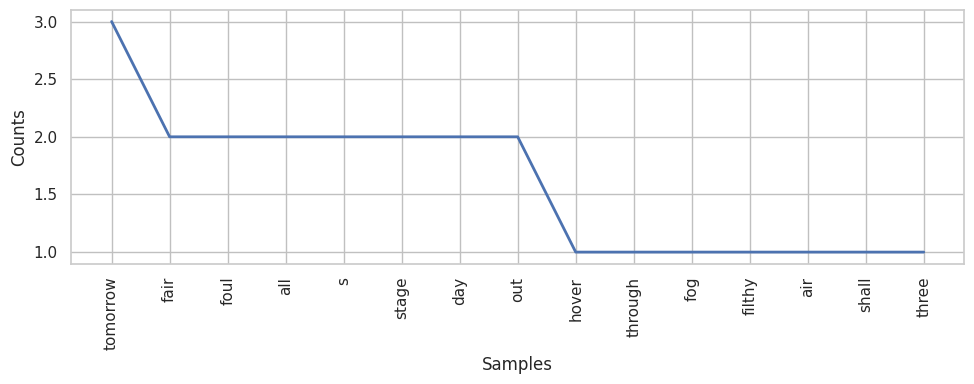

In [68]:
english_stopwords = {
    'a','an','and','are','as','at','be','but','by','for','from','had','has','have','he','her','his',
    'i','in','is','it','its','of','on','or','our','she','that','the','their','them','they','this','to',
    'was','we','were','what','when','which','who','will','with','you','your'
}
filtered_words = [w for w in macbeth_words if w not in english_stopwords]
freq = FreqDist(filtered_words)
display(pd.DataFrame(freq.most_common(15), columns=['Từ', 'Tần số']))

plt.figure(figsize=(10, 4))
freq.plot(15, cumulative=False)
plt.tight_layout(); plt.show(); plt.close()

### 03. Rút trích từ dài, từ chứa chuỗi và từ xuất hiện nhiều

In [69]:
long_words = sorted({w for w in macbeth_words if len(w) > 8})
contains_ow = sorted({w for w in macbeth_words if 'ow' in w})
frequent_long = [(w, n) for w, n in freq.most_common() if len(w) > 4 and n >= 2]
print('Từ dài hơn 8 ký tự:', long_words)
print("Từ chứa 'ow':", contains_ow)
print('Từ dài xuất hiện từ 2 lần:', frequent_long)

Từ dài hơn 8 ký tự: ['lightning']
Từ chứa 'ow': ['power', 'shadow', 'sorrow', 'tomorrow']
Từ dài xuất hiện từ 2 lần: [('tomorrow', 3), ('stage', 2)]


## Phần 03: N-gram và Collocation

### 01. Bigrams, Trigrams và Collocations

In [70]:
bigram_freq = FreqDist(bigrams(filtered_words))
trigram_freq = FreqDist(trigrams(filtered_words))
print('10 bigrams phổ biến:', bigram_freq.most_common(10))
print('10 trigrams phổ biến:', trigram_freq.most_common(10))

finder = BigramCollocationFinder.from_words(filtered_words)
collocations = finder.nbest(BigramAssocMeasures.likelihood_ratio, 10)
print('Collocations:', collocations)

10 bigrams phổ biến: [(('tomorrow', 'tomorrow'), 2), (('fair', 'foul'), 1), (('foul', 'foul'), 1), (('foul', 'fair'), 1), (('fair', 'hover'), 1), (('hover', 'through'), 1), (('through', 'fog'), 1), (('fog', 'filthy'), 1), (('filthy', 'air'), 1), (('air', 'shall'), 1)]
10 trigrams phổ biến: [(('fair', 'foul', 'foul'), 1), (('foul', 'foul', 'fair'), 1), (('foul', 'fair', 'hover'), 1), (('fair', 'hover', 'through'), 1), (('hover', 'through', 'fog'), 1), (('through', 'fog', 'filthy'), 1), (('fog', 'filthy', 'air'), 1), (('filthy', 'air', 'shall'), 1), (('air', 'shall', 'three'), 1), (('shall', 'three', 'meet'), 1)]
Collocations: [('again', 'thunder'), ('air', 'shall'), ('ambition', 'brings'), ('brave', 'macbeth'), ('brief', 'candle'), ('brings', 'fear'), ('candle', 'life'), ('creeps', 'petty'), ('doubt', 'sorrow'), ('fear', 'doubt')]


## Phần 04: Phân tích văn bản và HTML

### 01. Phân tích một đoạn văn bản mô phỏng nội dung trên mạng

In [71]:
web_text = """
Data analysis transforms raw data into reliable information. Good analysts ask clear questions,
clean data carefully, visualize patterns, and communicate conclusions responsibly.
"""
web_tokens = [w.lower() for w in wordpunct_tokenize(web_text) if w.isalpha()]
web_freq = FreqDist(w for w in web_tokens if w not in english_stopwords)
display(pd.DataFrame(web_freq.most_common(), columns=['Từ', 'Tần số']))

,Từ,Tần số
0,data,3
1,analysis,1
2,transforms,1
3,raw,1
4,into,1
5,reliable,1
6,information,1
7,good,1
8,analysts,1
9,ask,1


### 02. Tách nội dung HTML bằng BeautifulSoup

In [72]:
from bs4 import BeautifulSoup
html = """
<html><head><title>NLTK Lab</title></head><body>
<h1>Text Analytics</h1><p>Natural language processing helps computers analyze text.</p>
<p>Tokenization, frequency analysis, and classification are common tasks.</p>
</body></html>
"""
soup = BeautifulSoup(html, 'html.parser')
html_text = soup.get_text(' ', strip=True)
html_words = [w.lower() for w in wordpunct_tokenize(html_text) if w.isalpha()]
print(html_text)
print(FreqDist(html_words).most_common(10))

NLTK Lab Text Analytics Natural language processing helps computers analyze text. Tokenization, frequency analysis, and classification are common tasks.
[('text', 2), ('nltk', 1), ('lab', 1), ('analytics', 1), ('natural', 1), ('language', 1), ('processing', 1), ('helps', 1), ('computers', 1), ('analyze', 1)]


## Phần 05: Phân loại cảm xúc văn bản

### 01. Chuẩn bị review tích cực và tiêu cực

In [73]:
positive_reviews = [
    'The movie was excellent good and inspiring',
    'I loved the great story and excellent acting',
    'A wonderful enjoyable film with a good ending',
    'Brilliant direction and beautiful enjoyable music',
    'The characters were charming great and memorable',
    'This was fun engaging good and uplifting',
    'An enjoyable excellent and impressive performance',
    'The plot was clever exciting and great',
    'A warm emotional good and delightful movie',
    'I loved this wonderful film and would watch it again',
    'A great and enjoyable movie with excellent acting',
    'I loved this good inspiring and wonderful film'
]
negative_reviews = [
    'The movie was terrible bad and boring',
    'I hated the poor story and terrible acting',
    'A bad boring film with a disappointing ending',
    'Poor direction and annoying terrible music',
    'The characters were dull bad and forgettable',
    'This was slow boring poor and tiring',
    'An unpleasant terrible and disappointing performance',
    'The plot was messy pointless and bad',
    'A cold empty poor and frustrating movie',
    'I hated this boring film and would never watch it again',
    'A bad and boring movie with terrible acting',
    'I hated this poor disappointing and terrible film'
]

# Chia dữ liệu theo từng lớp để tập huấn luyện và kiểm tra luôn cân bằng.
train_documents = ([(text, 'positive') for text in positive_reviews[:10]] +
                   [(text, 'negative') for text in negative_reviews[:10]])
test_documents = ([(text, 'positive') for text in positive_reviews[10:]] +
                  [(text, 'negative') for text in negative_reviews[10:]])
random.Random(SEED).shuffle(train_documents)
random.Random(SEED + 1).shuffle(test_documents)
print('Số mẫu huấn luyện:', len(train_documents))
print('Số mẫu kiểm tra:', len(test_documents))

Số mẫu huấn luyện: 20
Số mẫu kiểm tra: 4


### 02. Xây dựng Naive Bayes Classifier

In [74]:
all_review_words = [
    w.lower()
    for text, _ in train_documents
    for w in wordpunct_tokenize(text)
    if w.isalpha()
]
word_features = [word for word, _ in FreqDist(all_review_words).most_common(80)]

def review_features(text):
    words = set(w.lower() for w in wordpunct_tokenize(text) if w.isalpha())
    return {f'contains({word})': word in words for word in word_features}

train_set = [(review_features(text), label) for text, label in train_documents]
test_set = [(review_features(text), label) for text, label in test_documents]
classifier = nltk.NaiveBayesClassifier.train(train_set)
accuracy = nltk.classify.accuracy(classifier, test_set)
print('Độ chính xác tập kiểm tra:', round(accuracy, 3))
for text, actual in test_documents:
    predicted = classifier.classify(review_features(text))
    print(f'- Thực tế: {actual:8s} | Dự đoán: {predicted:8s} | {text}')
classifier.show_most_informative_features(10)

Độ chính xác tập kiểm tra: 1.0
- Thực tế: negative | Dự đoán: negative | A bad and boring movie with terrible acting
- Thực tế: negative | Dự đoán: negative | I hated this poor disappointing and terrible film
- Thực tế: positive | Dự đoán: positive | I loved this good inspiring and wonderful film
- Thực tế: positive | Dự đoán: positive | A great and enjoyable movie with excellent acting
Most Informative Features
           contains(bad) = False          positi : negati =      1.6 : 1.0
        contains(boring) = False          positi : negati =      1.6 : 1.0
          contains(good) = False          negati : positi =      1.6 : 1.0
          contains(poor) = False          positi : negati =      1.6 : 1.0
      contains(terrible) = False          positi : negati =      1.6 : 1.0
     contains(enjoyable) = False          negati : positi =      1.4 : 1.0
     contains(excellent) = False          negati : positi =      1.4 : 1.0
         contains(great) = False          negati : positi =

### 03. Phân loại review mới

In [75]:
new_reviews = [
    'The story is exciting and the actors are wonderful',
    'The film is boring confusing and disappointing'
]
for review in new_reviews:
    print(classifier.classify(review_features(review)), '->', review)

positive -> The story is exciting and the actors are wonderful
negative -> The film is boring confusing and disappointing


## Phần 06: Bài tập Stopwords, WordNet và POS

### 01. Liệt kê các corpus NLTK thường dùng

In [76]:
common_corpora = ['gutenberg', 'brown', 'reuters', 'movie_reviews', 'names', 'stopwords', 'wordnet', 'treebank']
print(common_corpora)

['gutenberg', 'brown', 'reuters', 'movie_reviews', 'names', 'stopwords', 'wordnet', 'treebank']


### 02. Stopwords theo nhiều ngôn ngữ

In [77]:
stopwords_by_language = {
    'english': sorted(english_stopwords),
    'vietnamese': ['bị', 'bởi', 'các', 'cho', 'của', 'đã', 'đang', 'được', 'là', 'một', 'những', 'và', 'với'],
    'french': ['alors', 'au', 'aux', 'avec', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'et', 'la', 'le', 'les', 'un', 'une']
}
for language, words in stopwords_by_language.items():
    print(language, '–', len(words), 'từ:', words[:12])

english – 45 từ: ['a', 'an', 'and', 'are', 'as', 'at', 'be', 'but', 'by', 'for', 'from', 'had']
vietnamese – 13 từ: ['bị', 'bởi', 'các', 'cho', 'của', 'đã', 'đang', 'được', 'là', 'một', 'những', 'và']
french – 16 từ: ['alors', 'au', 'aux', 'avec', 'ce', 'ces', 'dans', 'de', 'des', 'du', 'et', 'la']


### 03. Kiểm tra và loại bỏ stopwords

In [78]:
def check_stopword(word, language='english'):
    return word.lower() in set(stopwords_by_language.get(language, []))

def remove_stopwords(text, language='english'):
    stop_set = set(stopwords_by_language.get(language, []))
    return ' '.join(w for w in wordpunct_tokenize(text) if w.lower() not in stop_set and w not in string.punctuation)

print("'the' là stopword:", check_stopword('the'))
print(remove_stopwords('Data analysis is a useful process for finding patterns in the data.'))

'the' là stopword: True
Data analysis useful process finding patterns data


### 04. Định nghĩa, từ đồng nghĩa và trái nghĩa bằng từ điển nhỏ

In [79]:
mini_wordnet = {
    'good': {'definition': 'having desirable or positive qualities', 'synonyms': ['great', 'fine', 'positive'], 'antonyms': ['bad', 'poor']},
    'happy': {'definition': 'feeling or showing pleasure', 'synonyms': ['glad', 'joyful', 'pleased'], 'antonyms': ['sad', 'unhappy']},
    'analyze': {'definition': 'examine something methodically', 'synonyms': ['examine', 'study', 'inspect'], 'antonyms': ['ignore']},
}

def lexical_information(word):
    return mini_wordnet.get(word.lower(), {'definition': 'Không có trong từ điển nhỏ', 'synonyms': [], 'antonyms': []})

for word in ['good', 'happy', 'analyze']:
    print(word, '->', lexical_information(word))

good -> {'definition': 'having desirable or positive qualities', 'synonyms': ['great', 'fine', 'positive'], 'antonyms': ['bad', 'poor']}
happy -> {'definition': 'feeling or showing pleasure', 'synonyms': ['glad', 'joyful', 'pleased'], 'antonyms': ['sad', 'unhappy']}
analyze -> {'definition': 'examine something methodically', 'synonyms': ['examine', 'study', 'inspect'], 'antonyms': ['ignore']}


### 05. Gắn nhãn POS bằng quy tắc và biểu thức chính quy

In [80]:
def simple_pos_tag(tokens):
    tagged = []
    for token in tokens:
        lower = token.lower()
        if re.fullmatch(r'\d+(\.\d+)?', token): tag = 'CD'
        elif lower.endswith('ing'): tag = 'VBG'
        elif lower.endswith('ed'): tag = 'VBD'
        elif lower.endswith('ly'): tag = 'RB'
        elif lower in {'a', 'an', 'the'}: tag = 'DT'
        elif lower in {'is', 'am', 'are', 'was', 'were', 'be'}: tag = 'VB'
        elif token[:1].isupper(): tag = 'NNP'
        else: tag = 'NN'
        tagged.append((token, tag))
    return tagged

sample_sentence = wordpunct_tokenize('The analyst is carefully studying 100 records.')
print(simple_pos_tag(sample_sentence))

[('The', 'DT'), ('analyst', 'NN'), ('is', 'VB'), ('carefully', 'RB'), ('studying', 'VBG'), ('100', 'CD'), ('records', 'NN'), ('.', 'NN')]


### 06. So sánh mức độ giống nhau của danh từ và động từ

In [81]:
from difflib import SequenceMatcher

def word_similarity(word1, word2):
    return round(SequenceMatcher(None, word1.lower(), word2.lower()).ratio(), 3)

print('car – automobile:', word_similarity('car', 'automobile'))
print('run – running:', word_similarity('run', 'running'))

car – automobile: 0.154
run – running: 0.6


## Phần 07: Phân tích tên và dự đoán giới tính

### 01. Chuẩn bị danh sách tên nam và nữ

Số tên nam: 20 | Số tên nữ: 20


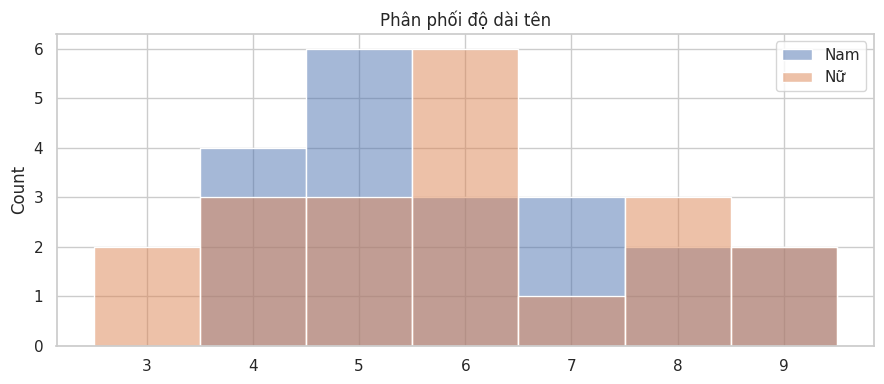

In [82]:
male_names = ['Liam','Noah','Oliver','James','Elijah','William','Henry','Lucas','Benjamin','Theodore','Jack','Levi','Alexander','Jackson','Mateo','Daniel','Michael','Mason','Sebastian','Ethan']
female_names = ['Olivia','Emma','Amelia','Sophia','Charlotte','Ava','Isabella','Mia','Luna','Harper','Camila','Sofia','Scarlett','Elizabeth','Eleanor','Emily','Chloe','Mila','Violet','Penelope']
print('Số tên nam:', len(male_names), '| Số tên nữ:', len(female_names))

plt.figure(figsize=(9, 4))
sns.histplot([len(n) for n in male_names], discrete=True, label='Nam', alpha=0.5, color='C0')
sns.histplot([len(n) for n in female_names], discrete=True, label='Nữ', alpha=0.5, color='C1')
plt.legend(); plt.title('Phân phối độ dài tên')
plt.tight_layout(); plt.show(); plt.close()

### 02. In 15 tên ngẫu nhiên được gắn nhãn

In [83]:
labeled_names = [(name, 'male') for name in male_names] + [(name, 'female') for name in female_names]
rng = random.Random(SEED)
rng.shuffle(labeled_names)
for item in labeled_names[:15]:
    print(item)

('Theodore', 'male')
('James', 'male')
('Jack', 'male')
('Chloe', 'female')
('Ava', 'female')
('Charlotte', 'female')
('Camila', 'female')
('Levi', 'male')
('Elijah', 'male')
('Scarlett', 'female')
('Emma', 'female')
('Luna', 'female')
('Sophia', 'female')
('Sebastian', 'male')
('Alexander', 'male')


### 03. Trích xuất ký tự cuối và xây dựng classifier

In [84]:
def gender_features(name):
    lower = name.lower()
    return {
        'last_letter': lower[-1],
        'last_two': lower[-2:],
        'length': len(lower),
        'ends_vowel': lower[-1] in 'aeiou'
    }

feature_names = [(gender_features(name), label) for name, label in labeled_names]
train_names, test_names = feature_names[:30], feature_names[30:]
gender_classifier = nltk.NaiveBayesClassifier.train(train_names)
print('Accuracy:', round(nltk.classify.accuracy(gender_classifier, test_names), 3))
for name in ['Anna', 'Michael', 'Sophia', 'Daniel']:
    print(name, '->', gender_classifier.classify(gender_features(name)))

Accuracy: 0.9
Anna -> female
Michael -> male
Sophia -> female
Daniel -> male


### 04. So sánh ký tự cuối giữa hai nhóm tên

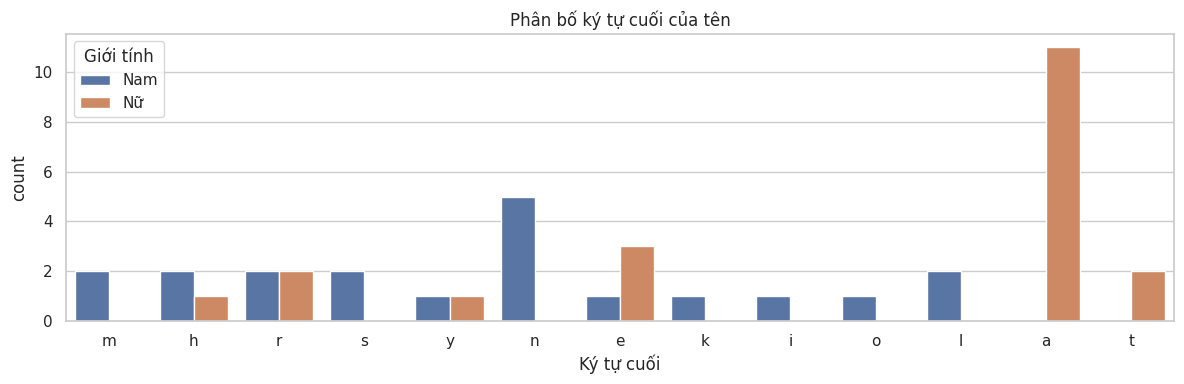

In [85]:
last_letter_rows = []
for name in male_names:
    last_letter_rows.append({'Ký tự cuối': name[-1].lower(), 'Giới tính': 'Nam'})
for name in female_names:
    last_letter_rows.append({'Ký tự cuối': name[-1].lower(), 'Giới tính': 'Nữ'})
last_letter_df = pd.DataFrame(last_letter_rows)
plt.figure(figsize=(12, 4))
sns.countplot(data=last_letter_df, x='Ký tự cuối', hue='Giới tính')
plt.title('Phân bố ký tự cuối của tên')
plt.tight_layout(); plt.show(); plt.close()

# KẾT THÚC BÀI TỔNG HỢP 07 LAB

Toàn bộ các Lab đã được sắp xếp theo cấu trúc thống nhất và có thể chạy tuần tự bằng **Run All**.